In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

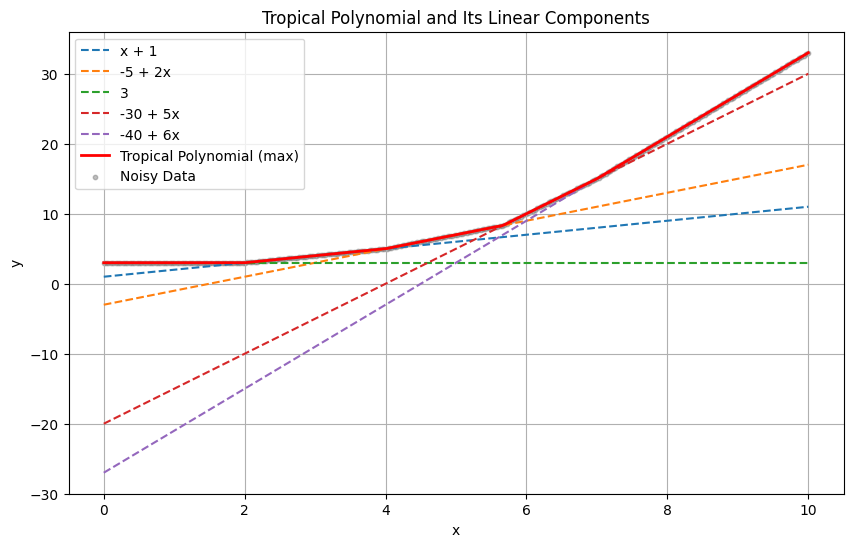

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tropical polynomial components ---
def tropical_components(x):
    f1 = x + 1
    f2 = -3 + 2 * x
    f3 = np.full_like(x, 3)
    f4 = -20 + 5 * x
    f5 = -27 + 6 * x
    return f1, f2, f3, f4, f5

def tropical_poly(x):
    return np.maximum.reduce(tropical_components(x))

# --- Data generation ---
np.random.seed(0)
x_vals = np.linspace(0, 10, 300)
f1, f2, f3, f4, f5 = tropical_components(x_vals)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.01, size=len(x_vals))

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(x_vals, f1, '--', label='x + 1')
plt.plot(x_vals, f2, '--', label='-5 + 2x')
plt.plot(x_vals, f3, '--', label='3')
plt.plot(x_vals, f4, '--', label='-30 + 5x')
plt.plot(x_vals, f5, '--', label='-40 + 6x')
plt.plot(x_vals, y_true, 'r-', linewidth=2, label='Tropical Polynomial (max)')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Tropical Polynomial and Its Linear Components')
plt.legend()
plt.grid(True)
plt.show()


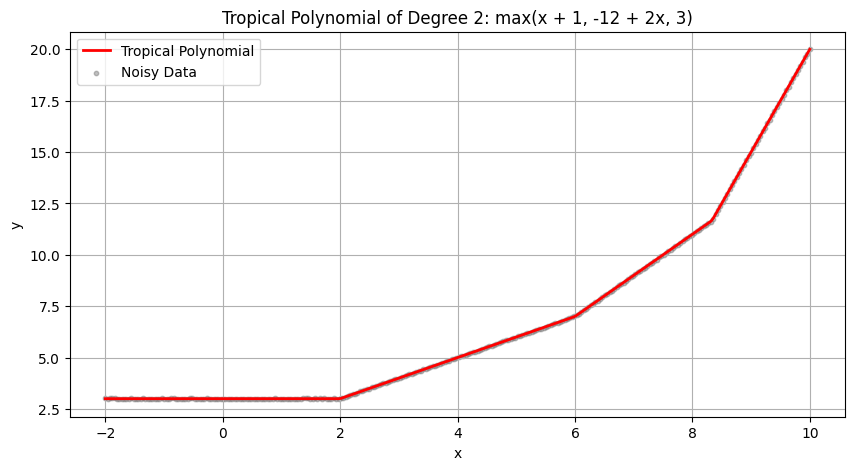

In [4]:
# --- Tropical polynomial of degree 2 ---
def tropical_poly(x):
    return np.maximum.reduce([x + 1, -5 + 2 * x, np.full_like(x, 3), -30 + 5*x, -40 + 6*x])


# --- Génération des données ---
np.random.seed(0)
x_vals = np.linspace(-2, 10, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.01, size=len(x_vals))

# --- Affichage ---
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r-', linewidth=2, label='Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Tropical Polynomial of Degree 2: max(x + 1, -12 + 2x, 3)')
plt.grid(True)
plt.legend()
plt.show()


In [5]:
# --- Helpers ---
def median_point_in_range(x, y, xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    x_filtered = x[mask]
    y_filtered = y[mask]

    if len(y_filtered) == 0:
        return None
    sorted_idx = np.argsort(y_filtered)
    median_idx = len(sorted_idx) // 2
    y_median = y_filtered[sorted_idx[median_idx]]
    x_median = x_filtered[sorted_idx[median_idx]]
    return x_median, y_median


In [6]:
# Choose a range to test the function
xmin_test = 12
xmax_test = 13

# Call the function
median_pt = median_point_in_range(x_vals, y_noisy, xmin_test, xmax_test)

# Display the result
if median_pt is not None:
    print(f"Median point in x ∈ [{xmin_test}, {xmax_test}]: (x = {median_pt[0]:.3f}, y = {median_pt[1]:.3f})")
else:
    print("No points found in the given x range.")


No points found in the given x range.


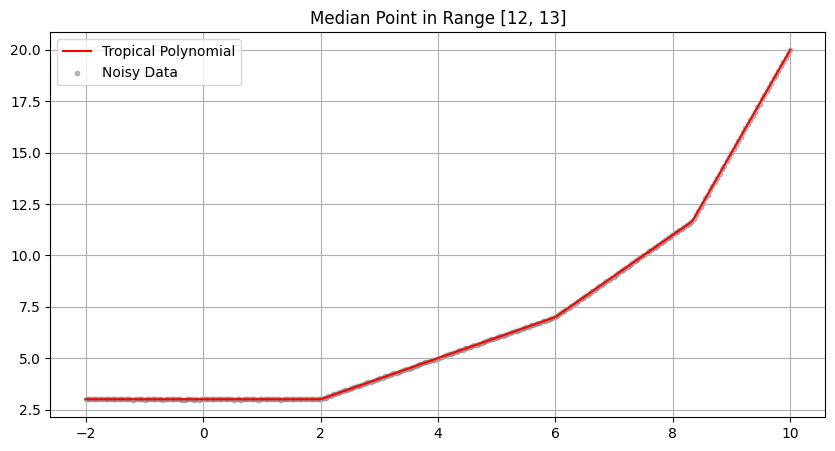

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r-', label='Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
if median_pt is not None:
    plt.plot(median_pt[0], median_pt[1], 'bo', markersize=5, label='Median Point')
    plt.axvline(x=xmin_test, color='green', linestyle='--', alpha=0.5)
    plt.axvline(x=xmax_test, color='green', linestyle='--', alpha=0.5)
plt.legend()
plt.title(f"Median Point in Range [{xmin_test}, {xmax_test}]")
plt.grid(True)
plt.show()


In [8]:
def line_from_two_points(pt1, pt2, x_range):
    if pt1 is None or pt2 is None:
        return 0, 0, np.zeros_like(x_range), np.inf
    x1, y1 = pt1
    x2, y2 = pt2
    a = 0 if x2 == x1 else (y2 - y1) / (x2 - x1)
    b = y1 - a * x1
    y_pred = a * x_range + b
    return a, b, y_pred

In [9]:
# Choix de deux points (exemple arbitraire ici)
#pt1 = (0, tropical_poly(0))
pt1 = (7.5 , 8.5 )

#pt2 = (5, tropical_poly(5))
pt2 = (12.9, 13.7 )

# Calcul de la droite
a, b, y_line = line_from_two_points(pt1, pt2, x_vals)

# Affichage des infos
print(f"Line passing through {pt1} and {pt2}: y = {a:.2f}x + {b:.2f}")


Line passing through (7.5, 8.5) and (12.9, 13.7): y = 0.96x + 1.28


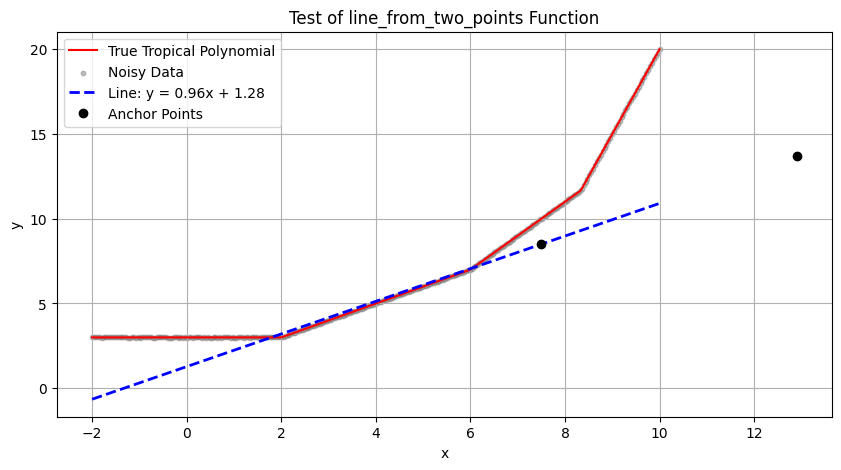

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r-', label='True Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
plt.plot(x_vals, y_line, 'b--', linewidth=2, label=f"Line: y = {a:.2f}x + {b:.2f}")
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], 'ko', label='Anchor Points')
plt.title("Test of line_from_two_points Function")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()


In [11]:
def compute_error(x, y, y_pred, mask):
    return np.mean((y[mask] - y_pred[mask])**2) if np.any(mask) else np.nan

Line passing through (7.5, 8.5) and (12.9, 13.7): y = 0.96x + 1.28
🔍 MSE between tropical function and line over [8, 12]: 31.9919


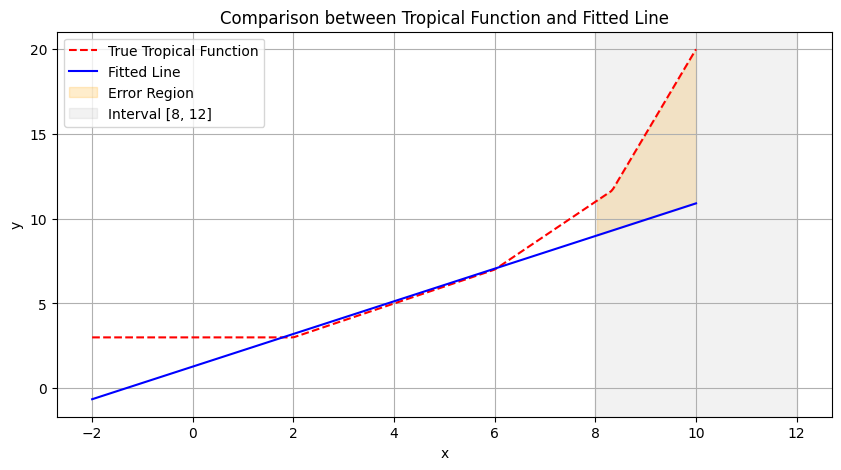

In [12]:
# --- Définir les deux points pour la droite ---
pt1 = (7.5, 8.5)
pt2 = (12.9, 13.7)

# --- Générer la droite ---
a, b, y_pred_line = line_from_two_points(pt1, pt2, x_vals)
print(f"Line passing through {pt1} and {pt2}: y = {a:.2f}x + {b:.2f}")

# --- Choisir un intervalle de comparaison ---
xmin, xmax = 8, 12
mask_interval = (x_vals >= xmin) & (x_vals <= xmax)

# --- Calcul de l'erreur sur l'intervalle ---
error_interval = compute_error(x_vals, y_true, y_pred_line, mask_interval)
print(f"🔍 MSE between tropical function and line over [{xmin}, {xmax}]: {error_interval:.4f}")

# --- Visualisation ---
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r--', label='True Tropical Function')
plt.plot(x_vals, y_pred_line, 'b-', label='Fitted Line')
plt.fill_between(x_vals, y_true, y_pred_line, where=mask_interval, color='orange', alpha=0.2, label='Error Region')
plt.axvspan(xmin, xmax, color='gray', alpha=0.1, label=f'Interval [{xmin}, {xmax}]')
plt.title("Comparison between Tropical Function and Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


❌ MSE between predicted line and noisy data in [4, 12]: 11.1180


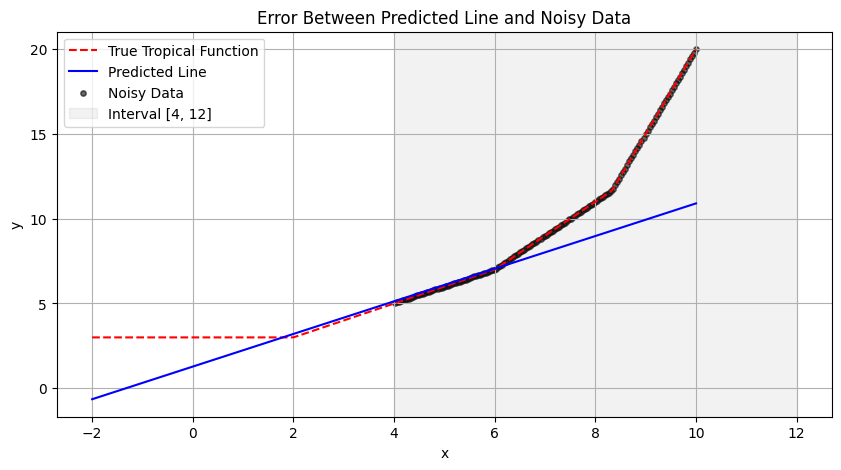

In [13]:
# --- Intervalle à tester ---
xmin, xmax = 4, 12
mask_interval = (x_vals >= xmin) & (x_vals <= xmax)

# --- Calcul de l'erreur entre la droite et les points bruités ---
error_noisy = compute_error(x_vals, y_noisy, y_pred_line, mask_interval)
print(f"❌ MSE between predicted line and noisy data in [{xmin}, {xmax}]: {error_noisy:.4f}")

# --- Visualisation ---
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r--', label='True Tropical Function')
plt.plot(x_vals, y_pred_line, 'b-', label='Predicted Line')
plt.scatter(x_vals[mask_interval], y_noisy[mask_interval], s=15, color='black', alpha=0.6, label='Noisy Data')
plt.axvspan(xmin, xmax, color='gray', alpha=0.1, label=f'Interval [{xmin}, {xmax}]')
plt.title("Error Between Predicted Line and Noisy Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


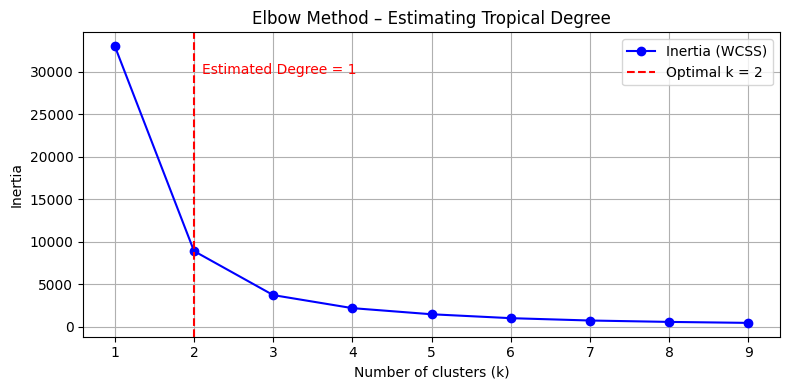

✅ Estimated tropical polynomial degree: 1


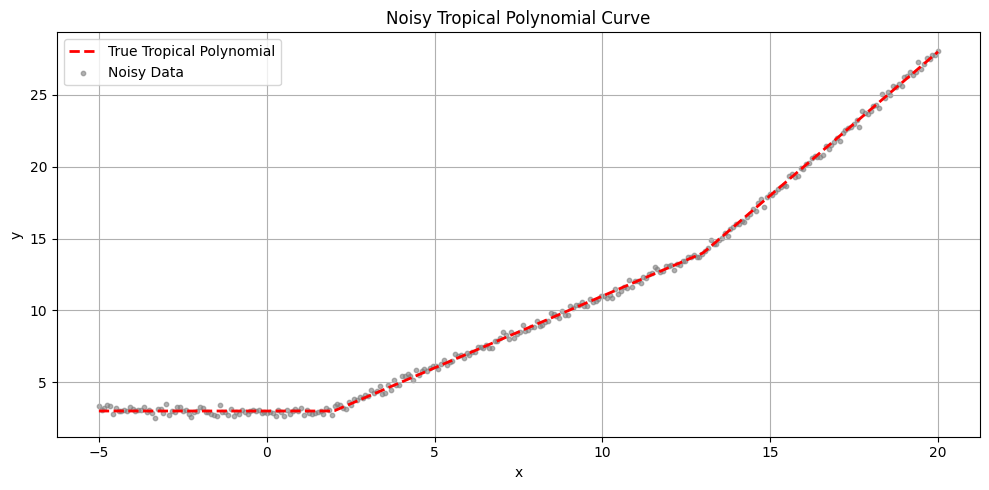

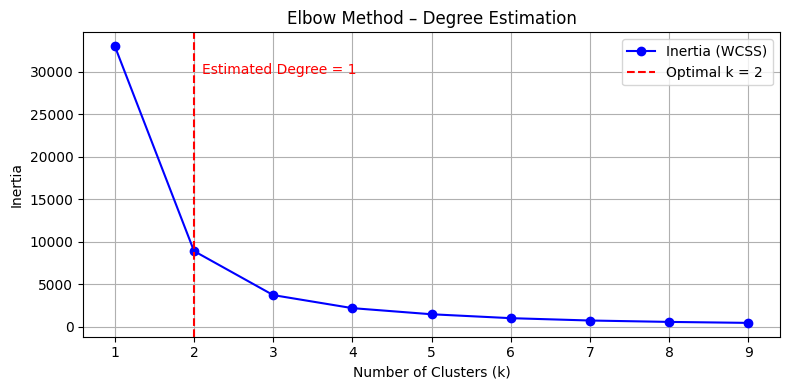

✅ Estimated tropical polynomial degree: 1


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(0)

# --- Simulate noisy tropical data (unknown polynomial to the algorithm) ---
def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])  # Degré 2 réel

x_vals = np.linspace(-5, 20, 300)
y_noisy = tropical_poly(x_vals) + np.random.normal(0, 0.2, size=len(x_vals))

# --- Step 1: Stack data into 2D array ---
data = np.column_stack((x_vals, y_noisy))

# --- Step 2: Try KMeans for k in a range and store inertia ---
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

# --- Step 3: Elbow detection via 2nd derivative ---
def find_elbow(inertias):
    second_derivative = []
    for i in range(1, len(inertias) - 1):
        curvature = inertias[i - 1] - 2 * inertias[i] + inertias[i + 1]
        second_derivative.append(curvature)
    elbow_index = np.argmax(second_derivative) + 2  # décalage car on a sauté k=1 et k=9
    return elbow_index

optimal_k = find_elbow(inertias)
estimated_degree = optimal_k - 1

# --- Step 4: Plot the elbow curve ---
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', label="Inertia (WCSS)", color='blue')
plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
plt.text(optimal_k + 0.1, max(inertias)*0.9, f"Estimated Degree = {estimated_degree}", color='red')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Estimating Tropical Degree")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Final Output ---
print(f"✅ Estimated tropical polynomial degree: {estimated_degree}")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(0)

# --- Tropical polynomial (unknown to the algorithm) ---
def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])  # Degré 2 réel

# --- Generate noisy data ---
x_vals = np.linspace(-5, 20, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.2, size=len(x_vals))
data = np.column_stack((x_vals, y_noisy))

# --- Plot the noisy tropical curve ---
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_true, 'r--', linewidth=2, label='True Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.6, label='Noisy Data')
plt.title("Noisy Tropical Polynomial Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- KMeans inertia for different k ---
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

# --- Find elbow: second derivative method ---
def find_elbow(inertias):
    second_derivative = []
    for i in range(1, len(inertias) - 1):
        curvature = inertias[i - 1] - 2 * inertias[i] + inertias[i + 1]
        second_derivative.append(curvature)
    elbow_index = np.argmax(second_derivative) + 2
    return elbow_index

optimal_k = find_elbow(inertias)
estimated_degree = optimal_k - 1

# --- Plot elbow graph ---
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', label="Inertia (WCSS)", color='blue')
plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
plt.text(optimal_k + 0.1, max(inertias)*0.9, f"Estimated Degree = {estimated_degree}", color='red')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Degree Estimation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Final result ---
print(f"✅ Estimated tropical polynomial degree: {estimated_degree}")


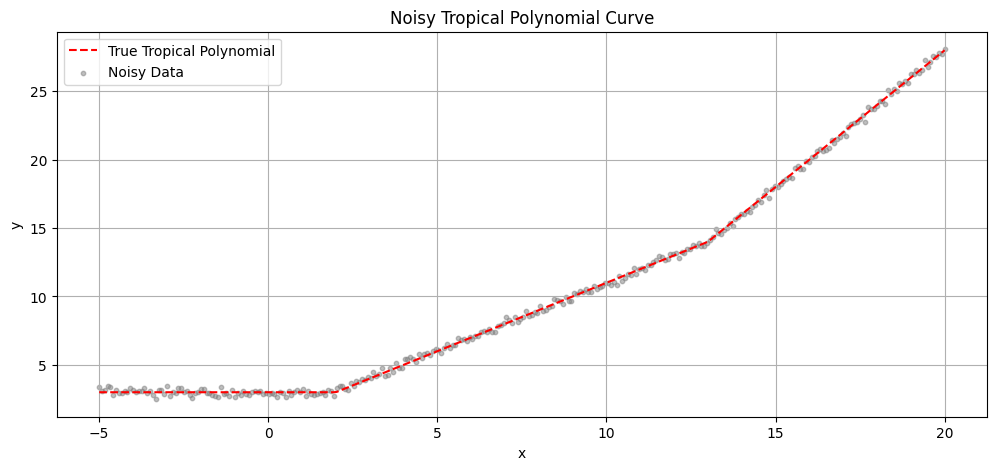

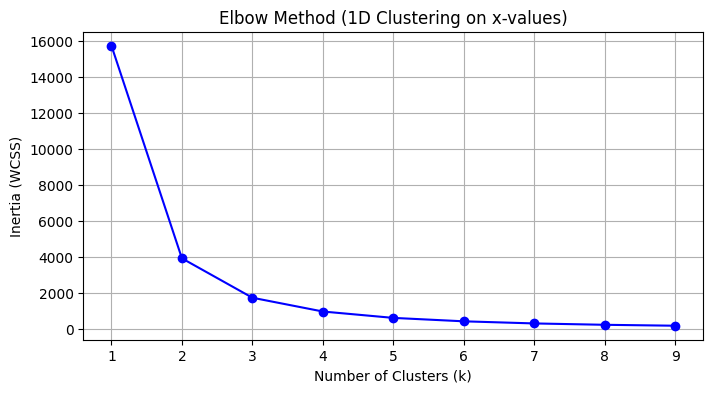

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Generate tropical polynomial data with noise ---
np.random.seed(0)

def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])

x_vals = np.linspace(-5, 20, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.2, size=len(x_vals))

# --- Plot noisy data and true function ---
plt.figure(figsize=(12, 5))
plt.plot(x_vals, y_true, 'r--', label='True Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noisy Tropical Polynomial Curve')
plt.grid(True)
plt.legend()
plt.show()

# --- Elbow method using clustering on x-values only ---
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(x_vals.reshape(-1, 1))
    inertias.append(kmeans.inertia_)

# --- Plot elbow curve ---
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='blue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method (1D Clustering on x-values)")
plt.grid(True)
plt.show()


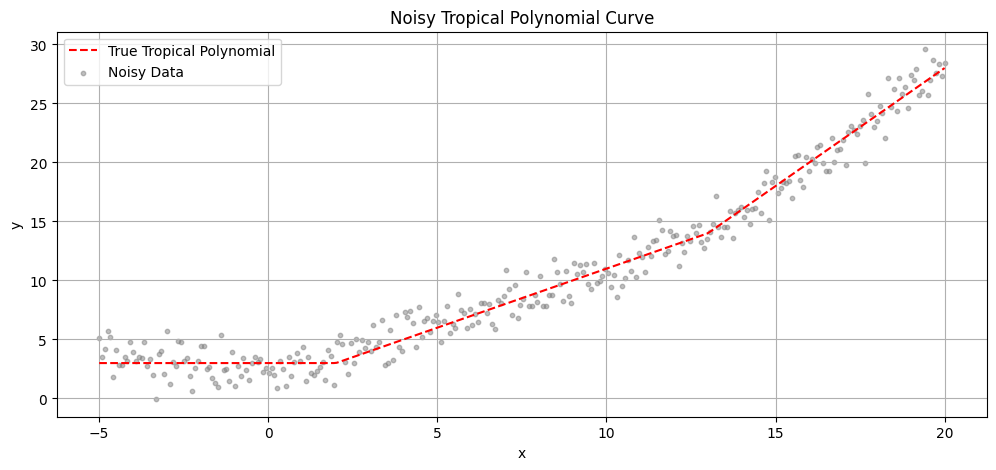

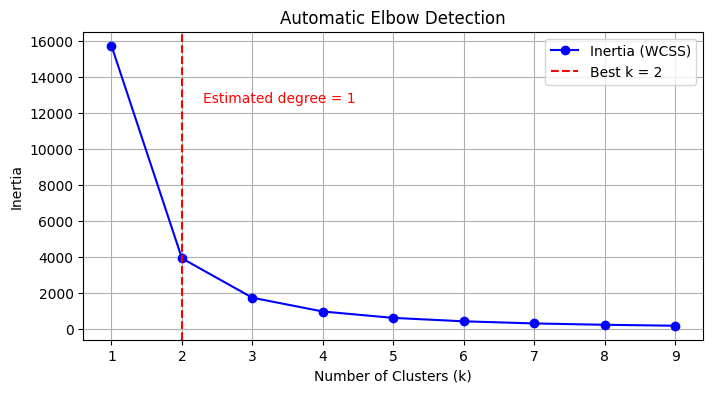

✅ Estimated best number of clusters: 2
✅ Estimated degree of the tropical polynomial: 1


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- 1. Generate noisy tropical polynomial data ---
np.random.seed(0)

def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])

x_vals = np.linspace(-5, 20, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 1.2, size=len(x_vals))

# --- 2. Plot the data ---
plt.figure(figsize=(12, 5))
plt.plot(x_vals, y_true, 'r--', label='True Tropical Polynomial')
plt.scatter(x_vals, y_noisy, s=10, alpha=0.5, color='gray', label='Noisy Data')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Tropical Polynomial Curve")
plt.grid(True)
plt.legend()
plt.show()

# --- 3. Try multiple KMeans and compute inertia for elbow method ---
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(x_vals.reshape(-1, 1))  # Clustering on x only
    inertias.append(kmeans.inertia_)

# --- 4. Automatic elbow detection using second derivative ---
def estimate_best_k(inertias):
    second_diffs = []
    for i in range(1, len(inertias)-1):
        second = inertias[i-1] - 2 * inertias[i] + inertias[i+1]
        second_diffs.append(second)
    elbow_index = np.argmax(second_diffs) + 2  # +2 because we skipped first and last
    return elbow_index

best_k = estimate_best_k(inertias)
estimated_degree = best_k - 1

# --- 5. Plot the elbow curve ---
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='blue', label="Inertia (WCSS)")
plt.axvline(best_k, color='red', linestyle='--', label=f"Best k = {best_k}")
plt.text(best_k + 0.3, max(inertias) * 0.8,
         f"Estimated degree = {estimated_degree}", color='red')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Automatic Elbow Detection")
plt.grid(True)
plt.legend()
plt.show()

# --- 6. Final output ---
print(f"✅ Estimated best number of clusters: {best_k}")
print(f"✅ Estimated degree of the tropical polynomial: {estimated_degree}")


Anchor points around thresholds: [(3.2775919732441476, 4.357989845933088), (11.638795986622075, 12.906101576509354)]
Initial thresholds: [ 3.333 11.667]


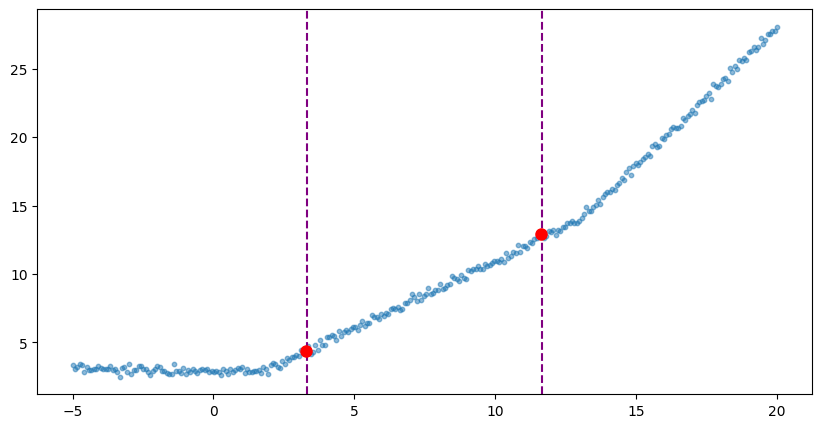

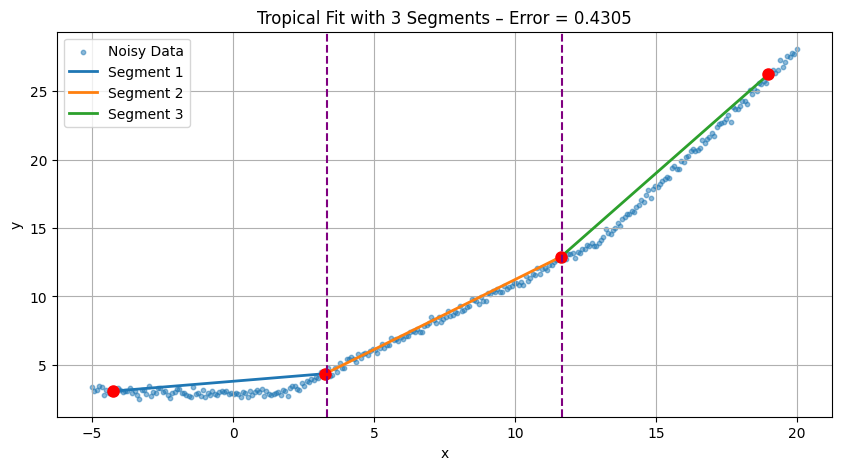

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Données tropicales bruitées ---
np.random.seed(0)

def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])

x_vals = np.linspace(-5, 20, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.2, size=len(x_vals))

# --- Étape : Calcul des points d'ancrage autour des seuils ---
def anchor_points_from_thresholds(x, y, thresholds, window=0.25):
    anchor_points = []
    for t in thresholds:
        mask = (x >= t - window) & (x <= t + window)
        if np.sum(mask) > 0:
            # point médian basé uniquement sur y
            y_vals = y[mask]
            x_vals = x[mask]
            sorted_idx = np.argsort(y_vals)
            mid_idx = len(sorted_idx) // 2
            x_median = x_vals[sorted_idx[mid_idx]]
            y_median = y_vals[sorted_idx[mid_idx]]
            anchor_points.append((x_median, y_median))
    return anchor_points

# --- Fonction d'initialisation et plot des seuils + anchor points ---
def tropical_regression_manual_k(x, y, k=3, n_iter=10, alpha=0.5):
    # Initial thresholds equally spaced
    thresholds = list(np.linspace(np.min(x), np.max(x), k+1)[1:-1])
    anchor_points = anchor_points_from_thresholds(x_vals, y_noisy, thresholds)
    print("Anchor points around thresholds:", anchor_points)

    print(f"Initial thresholds: {np.round(thresholds, 3)}")

    # Plot with initial thresholds and anchor points
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")
    
    for t in thresholds:
        plt.axvline(t, color='purple', linestyle='--', label=f"Threshold = {t:.2f}")
    
    for px, py in anchor_points:
        plt.plot(px, py, 'ro', markersize=8, label='Anchor Point')
        
            # Ajouter les extrémités (médiane à gauche et à droite des seuils)
    x_min, x_max = np.min(x), np.max(x)
    left_mask = x <= thresholds[0] - 0.5
    right_mask = x >= thresholds[-1] + 0.5

        # Récupère les extrémités gauche et droite des masques
    x_min, x_max = np.min(x), np.max(x)
    full_mask_left = x <= thresholds[0]
    full_mask_right = x > thresholds[-1]

    # POINT À GAUCHE : premier quart du masque gauche
    x_left = x[full_mask_left]
    y_left = y[full_mask_left]
    if len(x_left) >= 4:
        q1 = len(x_left) // 4
        pt_left = median_point_in_range(x_left[:q1], y_left[:q1], x_left[:q1].min(), x_left[:q1].max())
        if pt_left: anchor_points.insert(0, pt_left)

    # POINT À DROITE : dernier quart du masque droit
    x_right = x[full_mask_right]
    y_right = y[full_mask_right]
    if len(x_right) >= 4:
        q3 = len(x_right) // 4
        pt_right = median_point_in_range(x_right[-q3:], y_right[-q3:], x_right[-q3:].min(), x_right[-q3:].max())
        if pt_right: anchor_points.append(pt_right)

    # Trier les points par abscisse
    anchor_points = sorted(anchor_points, key=lambda p: p[0])

        # Tracer les segments et calculer l'erreur totale
    global_error = 0
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")

    for i in range(len(anchor_points) - 1):
        pt1 = anchor_points[i]
        pt2 = anchor_points[i + 1]
        a, b, y_pred = line_from_two_points(pt1, pt2, x)
        
        # Zone entre les deux x des points d’ancrage
        x1, x2 = pt1[0], pt2[0]
        mask = (x >= x1) & (x <= x2)
        
        error = compute_error(x, y, y_pred, mask)
        global_error += error * np.sum(mask)  # pondéré par le nombre de points

        # Tracé du segment
        plt.plot(x[mask], y_pred[mask], linewidth=2, label=f"Segment {i+1}")

    # Affichage des points d'ancrage
    for px, py in anchor_points:
        plt.plot(px, py, 'ro', markersize=8)

    # Seuils
    for t in thresholds:
        plt.axvline(t, color='purple', linestyle='--')

    plt.title(f"Tropical Fit with {len(anchor_points)-1} Segments – Error = {global_error/len(x):.4f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Exécution ---
tropical_regression_manual_k(x_vals, y_noisy, k=3)


Initial thresholds: [ 3.333 11.667]
Segment 1 | x ∈ [-4.25, 3.28] → MSE = 0.48251
Segment 2 | x ∈ [3.28, 12.14] → MSE = 0.06731
Segment 3 | x ∈ [12.14, 19.00] → MSE = 0.17102


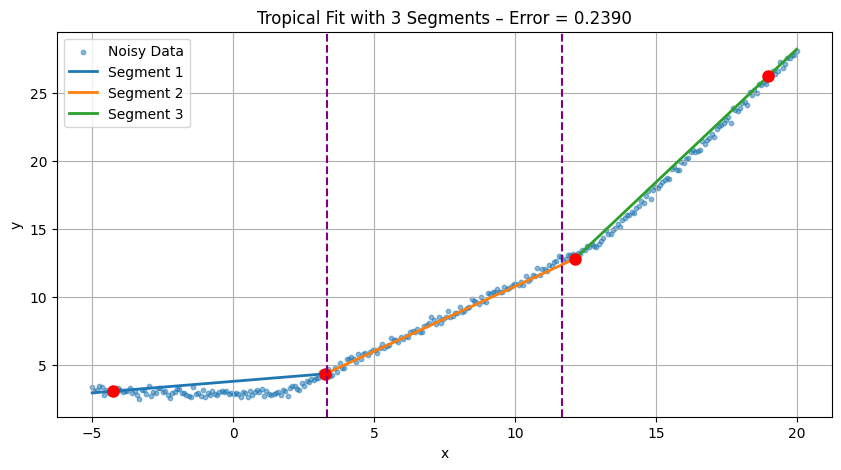

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Données tropicales bruitées ---
np.random.seed(0)

def tropical_poly(x):
    return np.maximum.reduce([x + 1, -12 + 2 * x, np.full_like(x, 3)])

x_vals = np.linspace(-5, 20, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.2, size=len(x_vals))

# --- Helpers ---
def median_point_in_range(x, y, xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    x_filtered = x[mask]
    y_filtered = y[mask]
    if len(y_filtered) == 0:
        return None
    sorted_idx = np.argsort(y_filtered)
    median_idx = len(sorted_idx) // 2
    y_median = y_filtered[sorted_idx[median_idx]]
    x_median = x_filtered[sorted_idx[median_idx]]
    return x_median, y_median

def line_from_two_points(pt1, pt2, x_range):
    if pt1 is None or pt2 is None:
        return 0, 0, np.zeros_like(x_range)
    x1, y1 = pt1
    x2, y2 = pt2
    a = 0 if x2 == x1 else (y2 - y1) / (x2 - x1)
    b = y1 - a * x1
    y_pred = a * x_range + b
    return a, b, y_pred

def compute_error(x, y, y_pred, mask):
    return np.mean((y[mask] - y_pred[mask])**2) if np.any(mask) else np.nan

def anchor_points_from_thresholds(x, y, thresholds, window):
    anchor_points = []
    for t in thresholds:
        mask = (x >= t - window) & (x <= t + window)
        if np.sum(mask) > 0:
            y_vals = y[mask]
            x_vals = x[mask]
            sorted_idx = np.argsort(y_vals)
            mid_idx = len(sorted_idx) // 2
            x_median = x_vals[sorted_idx[mid_idx]]
            y_median = y_vals[sorted_idx[mid_idx]]
            anchor_points.append((x_median, y_median))
    return anchor_points

# --- Tropical Regression avec tracé ---
def tropical_regression_manual_k(x, y, k=3,w=0.5):
    thresholds = list(np.linspace(np.min(x), np.max(x), k+1)[1:-1])
    print(f"Initial thresholds: {np.round(thresholds, 3)}")

    anchor_points = anchor_points_from_thresholds(x, y, thresholds,w)

    # --- Points extrêmes (quart gauche et droit) ---
    full_mask_left = x <= thresholds[0]
    full_mask_right = x > thresholds[-1]

    x_left, y_left = x[full_mask_left], y[full_mask_left]
    if len(x_left) >= 4:
        q1 = len(x_left) // 4
        pt_left = median_point_in_range(x_left[:q1], y_left[:q1], x_left[:q1].min(), x_left[:q1].max())
        if pt_left: anchor_points.insert(0, pt_left)

    x_right, y_right = x[full_mask_right], y[full_mask_right]
    if len(x_right) >= 4:
        q3 = len(x_right) // 4
        pt_right = median_point_in_range(x_right[-q3:], y_right[-q3:], x_right[-q3:].min(), x_right[-q3:].max())
        if pt_right: anchor_points.append(pt_right)

    anchor_points = sorted(anchor_points, key=lambda p: p[0])

    # --- Tracé et erreur ---
    global_error = 0
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")

    for i in range(len(anchor_points) - 1):
        pt1, pt2 = anchor_points[i], anchor_points[i + 1]
        a, b, y_pred = line_from_two_points(pt1, pt2, x)
        
        # Pour les extrémités, on étend le masque sur toute la gauche ou toute la droite
        if i == 0:
            mask = x <= pt2[0]
        elif i == len(anchor_points) - 2:
            mask = x >= pt1[0]
        else:
            mask = (x >= pt1[0]) & (x <= pt2[0])

        error = compute_error(x, y, y_pred, mask)
        print(f"Segment {i+1} | x ∈ [{pt1[0]:.2f}, {pt2[0]:.2f}] → MSE = {error:.5f}")

        global_error += error * np.sum(mask)
        plt.plot(x[mask], y_pred[mask], linewidth=2, label=f"Segment {i+1}")

    for px, py in anchor_points:
        plt.plot(px, py, 'ro', markersize=8)

    for t in thresholds:
        plt.axvline(t, color='purple', linestyle='--')

    plt.title(f"Tropical Fit with {len(anchor_points)-1} Segments – Error = {global_error/len(x):.4f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Exécution ---
tropical_regression_manual_k(x_vals, y_noisy, k=3, w=0.5)


In [19]:
# --- Tropical Regression avec itérations et ajustement des seuils ---
def tropical_regression_manual_k(x, y, k=3, n_iter=10, alpha=0.5, w=0.5):
    thresholds = list(np.linspace(np.min(x), np.max(x), k+1)[1:-1])
    print(f"Initial thresholds: {np.round(thresholds, 3)}")

    global_errors = []

    for it in range(n_iter):
        print(f"\n--- Iteration {it+1} ---")

        anchor_points = anchor_points_from_thresholds(x, y, thresholds)

        # --- Points extrêmes (quart gauche et droit) ---
        full_mask_left = x <= thresholds[0]
        full_mask_right = x > thresholds[-1]

        x_left, y_left = x[full_mask_left], y[full_mask_left]
        if len(x_left) >= 4:
            q1 = len(x_left) // 4
            pt_left = median_point_in_range(x_left[:q1], y_left[:q1], x_left[:q1].min(), x_left[:q1].max())
            if pt_left: anchor_points.insert(0, pt_left)

        x_right, y_right = x[full_mask_right], y[full_mask_right]
        if len(x_right) >= 4:
            q3 = len(x_right) // 4
            pt_right = median_point_in_range(x_right[-q3:], y_right[-q3:], x_right[-q3:].min(), x_right[-q3:].max())
            if pt_right: anchor_points.append(pt_right)

        anchor_points = sorted(anchor_points, key=lambda p: p[0])

        # --- Tracé et erreur ---
        global_error = 0
        errors = []

        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")

        for i in range(len(anchor_points) - 1):
            pt1, pt2 = anchor_points[i], anchor_points[i + 1]
            a, b, y_pred = line_from_two_points(pt1, pt2, x)

            # Étendre les extrémités
            if i == 0:
                mask = x <= pt2[0]
            elif i == len(anchor_points) - 2:
                mask = x >= pt1[0]
            else:
                mask = (x >= pt1[0]) & (x <= pt2[0])

            error = compute_error(x, y, y_pred, mask)
            errors.append(error)
            global_error += error * np.sum(mask)

            print(f"Segment {i+1} | x ∈ [{pt1[0]:.2f}, {pt2[0]:.2f}] → MSE = {error:.5f}")
            plt.plot(x[mask], y_pred[mask], linewidth=2, label=f"Segment {i+1}")

        # --- Affichage des points et seuils ---
        for px, py in anchor_points:
            plt.plot(px, py, 'ro', markersize=8)
        for t in thresholds:
            plt.axvline(t, color='purple', linestyle='--')
        plt.title(f"Iteration {it+1} – Global Error = {global_error/len(x):.4f}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

        # --- Déplacement des seuils ---
        for i in range(len(thresholds)):
            err_left = errors[i]
            err_right = errors[i + 1]
            move = alpha * (err_right - err_left)
            thresholds[i] += move
            print(f"Threshold {i+1} moved by {move:.4f} → new = {thresholds[i]:.4f}")
            
            
        global_errors.append(global_error / len(x))

    # --- Plot global error evolution ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_iter + 1), global_errors, marker='o', color='darkred')
    plt.title("Evolution of Global Error over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Global MSE")
    plt.grid(True)
    plt.show()

tropical_regression_manual_k(x_vals, y_noisy, k=3, n_iter=10, alpha=0.5, w=0.5)

Initial thresholds: [ 3.333 11.667]

--- Iteration 1 ---


TypeError: anchor_points_from_thresholds() missing 1 required positional argument: 'window'

Initial thresholds: [0.4 2.8 5.2 7.6]

--- Iteration 1 ---
Segment 1 | x ∈ [-1.44, 0.37] → MSE = 0.01079
Segment 2 | x ∈ [0.37, 2.78] → MSE = 0.18454
Segment 3 | x ∈ [2.78, 5.22] → MSE = 0.23377
Segment 4 | x ∈ [5.22, 7.59] → MSE = 0.75850
Segment 5 | x ∈ [7.59, 9.72] → MSE = 0.00948


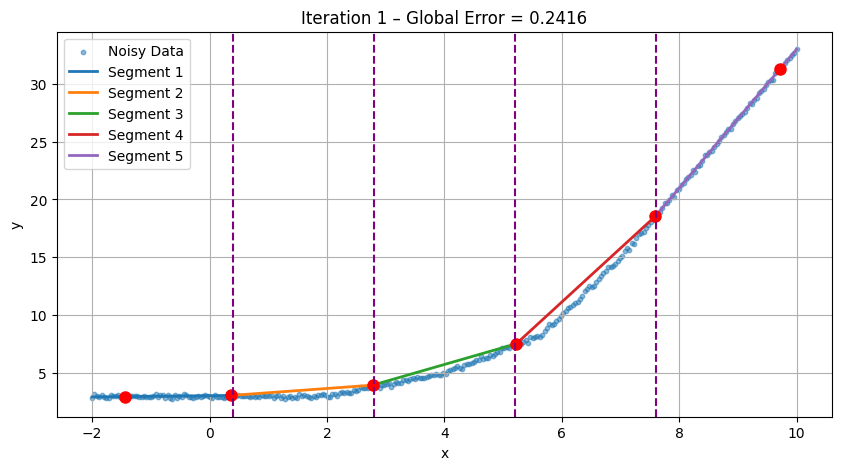

Threshold 1 moved by 0.3475 → new = 0.7475
Threshold 2 moved by 0.0985 → new = 2.8985
Threshold 3 moved by 1.0495 → new = 6.2495
Threshold 4 moved by -1.4981 → new = 6.1019

--- Iteration 2 ---
Segment 1 | x ∈ [-1.64, 0.73] → MSE = 0.00788
Segment 2 | x ∈ [0.73, 2.86] → MSE = 0.10857
Segment 3 | x ∈ [2.86, 6.11] → MSE = 1.22034
Segment 4 | x ∈ [6.11, 6.27] → MSE = 0.00113
Segment 5 | x ∈ [6.27, 9.60] → MSE = 0.05765


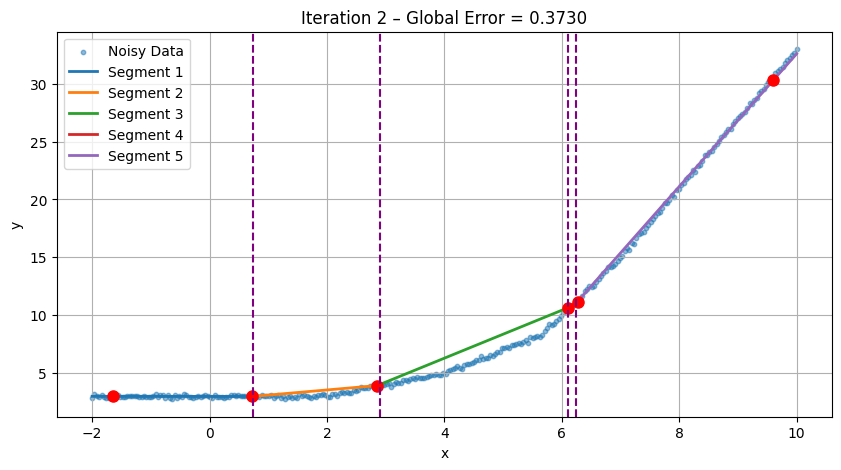

Threshold 1 moved by 0.2014 → new = 0.9489
Threshold 2 moved by 2.2235 → new = 5.1220
Threshold 3 moved by -2.4384 → new = 3.8111
Threshold 4 moved by 0.1130 → new = 6.2150

--- Iteration 3 ---
Segment 1 | x ∈ [-1.64, 0.97] → MSE = 0.00775
Segment 2 | x ∈ [0.97, 3.78] → MSE = 0.18125
Segment 3 | x ∈ [3.78, 5.14] → MSE = 0.05502
Segment 4 | x ∈ [5.14, 6.23] → MSE = 0.23258
Segment 5 | x ∈ [6.23, 9.60] → MSE = 0.08003


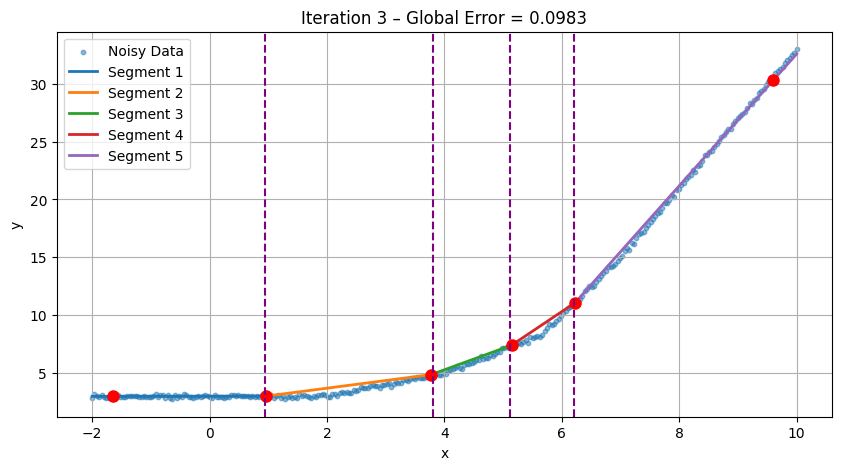

Threshold 1 moved by 0.3470 → new = 1.2959
Threshold 2 moved by -0.2525 → new = 4.8695
Threshold 3 moved by 0.3551 → new = 4.1662
Threshold 4 moved by -0.3051 → new = 5.9099

--- Iteration 4 ---
Segment 1 | x ∈ [-1.60, 1.33] → MSE = 0.00973
Segment 2 | x ∈ [1.33, 4.18] → MSE = 0.11643
Segment 3 | x ∈ [4.18, 4.86] → MSE = 0.01380
Segment 4 | x ∈ [4.86, 5.91] → MSE = 0.07547
Segment 5 | x ∈ [5.91, 9.52] → MSE = 0.18563


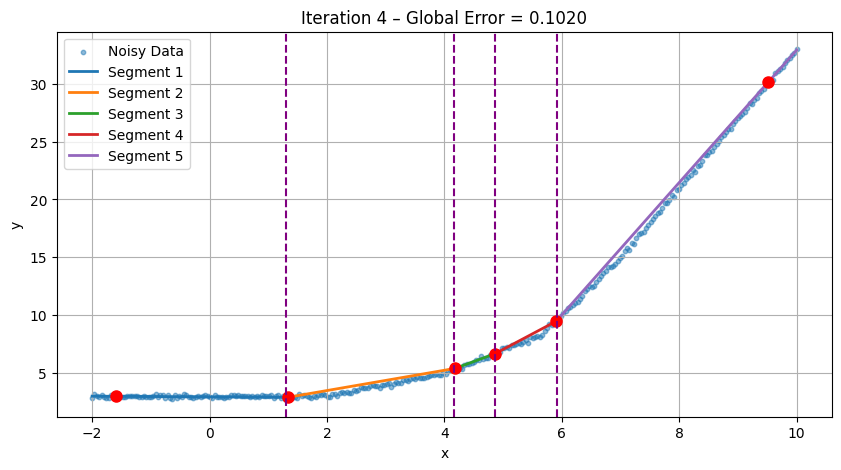

Threshold 1 moved by 0.2134 → new = 1.5093
Threshold 2 moved by -0.2053 → new = 4.6643
Threshold 3 moved by 0.1233 → new = 4.2895
Threshold 4 moved by 0.2203 → new = 6.1302

--- Iteration 5 ---
Segment 1 | x ∈ [-1.64, 1.53] → MSE = 0.02035
Segment 2 | x ∈ [1.53, 4.26] → MSE = 0.15797
Segment 3 | x ∈ [4.26, 4.70] → MSE = 0.01215
Segment 4 | x ∈ [4.70, 6.15] → MSE = 0.25258
Segment 5 | x ∈ [6.15, 9.60] → MSE = 0.09890


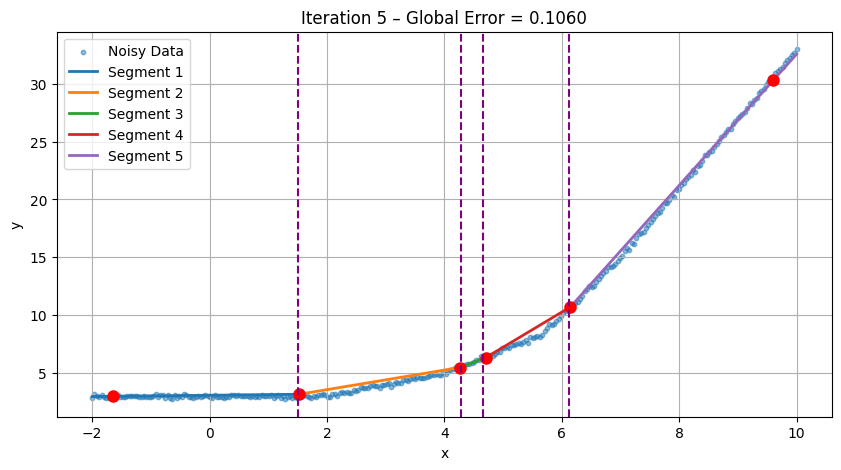

Threshold 1 moved by 0.2752 → new = 1.7845
Threshold 2 moved by -0.2916 → new = 4.3726
Threshold 3 moved by 0.4809 → new = 4.7704
Threshold 4 moved by -0.3074 → new = 5.8228

--- Iteration 6 ---
Segment 1 | x ∈ [-1.64, 1.77] → MSE = 0.00831
Segment 2 | x ∈ [1.77, 4.38] → MSE = 0.07637
Segment 3 | x ∈ [4.38, 4.78] → MSE = 0.01415
Segment 4 | x ∈ [4.78, 5.79] → MSE = 0.11271
Segment 5 | x ∈ [5.79, 9.52] → MSE = 0.37215


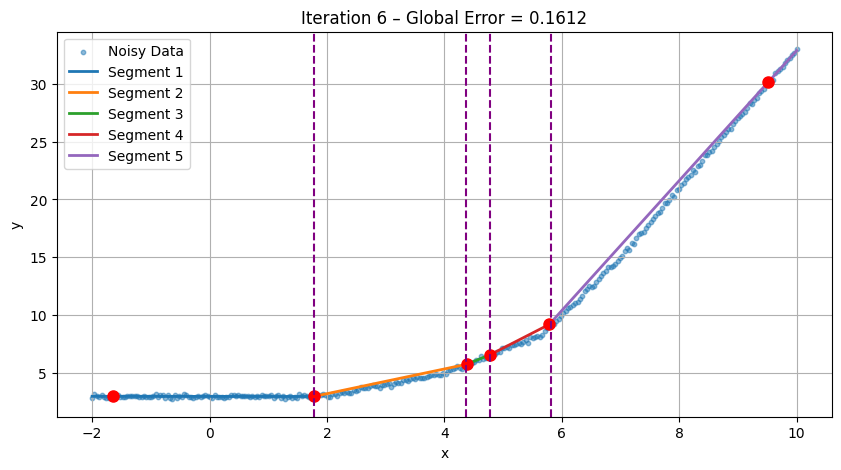

Threshold 1 moved by 0.1361 → new = 1.9206
Threshold 2 moved by -0.1244 → new = 4.2482
Threshold 3 moved by 0.1971 → new = 4.9675
Threshold 4 moved by 0.5189 → new = 6.3417

--- Iteration 7 ---
Segment 1 | x ∈ [-1.64, 1.93] → MSE = 0.01719
Segment 2 | x ∈ [1.93, 4.22] → MSE = 0.10351
Segment 3 | x ∈ [4.22, 4.98] → MSE = 0.06222
Segment 4 | x ∈ [4.98, 6.35] → MSE = 0.36494
Segment 5 | x ∈ [6.35, 9.60] → MSE = 0.05700


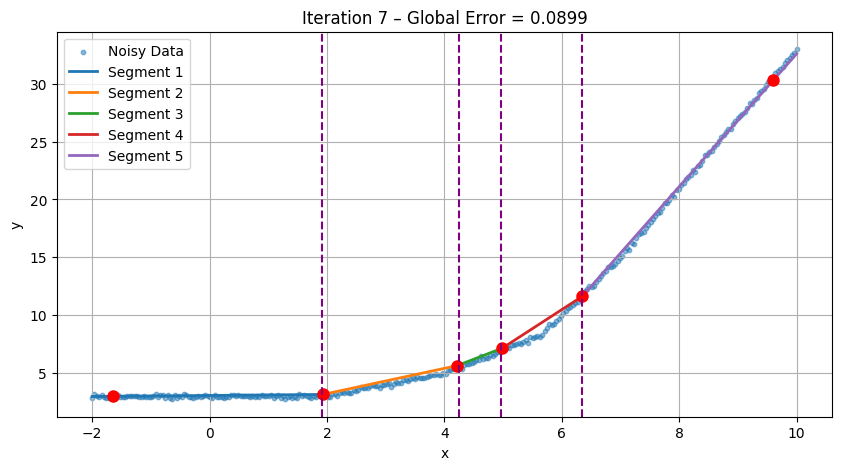

Threshold 1 moved by 0.1726 → new = 2.0933
Threshold 2 moved by -0.0826 → new = 4.1656
Threshold 3 moved by 0.6054 → new = 5.5729
Threshold 4 moved by -0.6159 → new = 5.7259

--- Iteration 8 ---
Segment 1 | x ∈ [-1.32, 2.13] → MSE = 0.01714
Segment 2 | x ∈ [2.13, 4.18] → MSE = 0.02466
Segment 3 | x ∈ [4.18, 5.59] → MSE = 0.01498
Segment 4 | x ∈ [5.59, 5.75] → MSE = 0.02006
Segment 5 | x ∈ [5.75, 9.52] → MSE = 0.30621


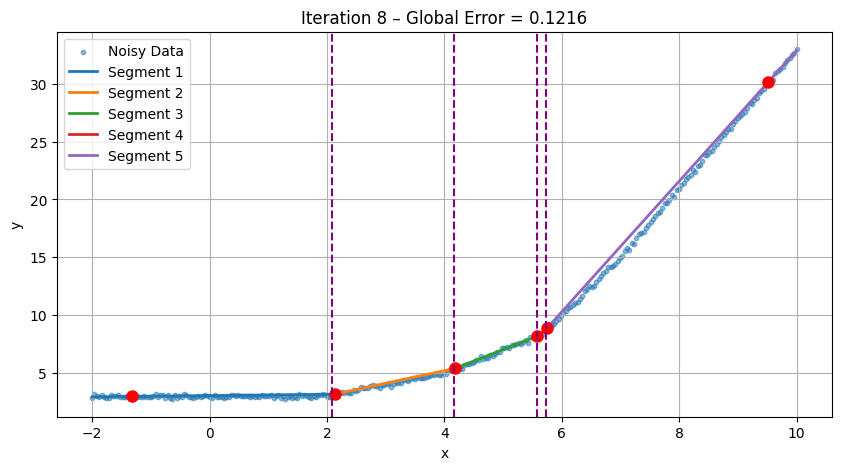

Threshold 1 moved by 0.0151 → new = 2.1083
Threshold 2 moved by -0.0194 → new = 4.1462
Threshold 3 moved by 0.0102 → new = 5.5831
Threshold 4 moved by 0.5723 → new = 6.2982

--- Iteration 9 ---
Segment 1 | x ∈ [-1.32, 2.09] → MSE = 0.01762
Segment 2 | x ∈ [2.09, 4.14] → MSE = 0.02307
Segment 3 | x ∈ [4.14, 5.63] → MSE = 0.01639
Segment 4 | x ∈ [5.63, 6.31] → MSE = 0.01205
Segment 5 | x ∈ [6.31, 9.60] → MSE = 0.05524


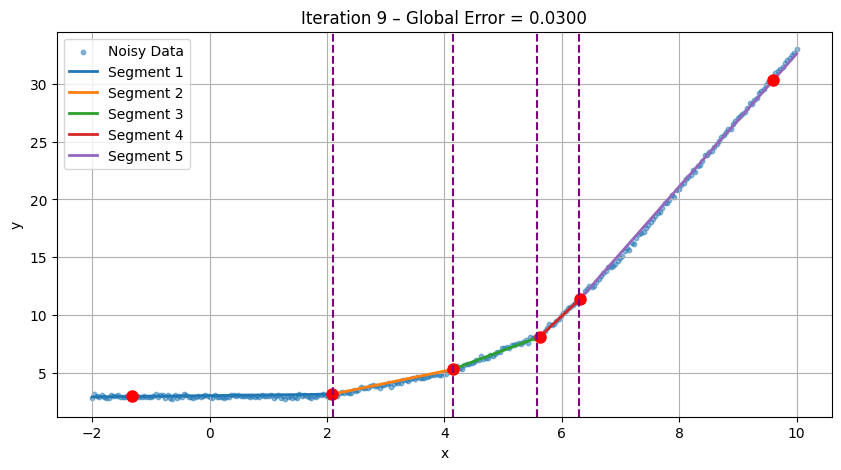

Threshold 1 moved by 0.0109 → new = 2.1192
Threshold 2 moved by -0.0134 → new = 4.1329
Threshold 3 moved by -0.0087 → new = 5.5744
Threshold 4 moved by 0.0864 → new = 6.3845

--- Iteration 10 ---
Segment 1 | x ∈ [-1.32, 2.09] → MSE = 0.01762
Segment 2 | x ∈ [2.09, 4.14] → MSE = 0.02307
Segment 3 | x ∈ [4.14, 5.59] → MSE = 0.01433
Segment 4 | x ∈ [5.59, 6.39] → MSE = 0.04530
Segment 5 | x ∈ [6.39, 9.56] → MSE = 0.12069


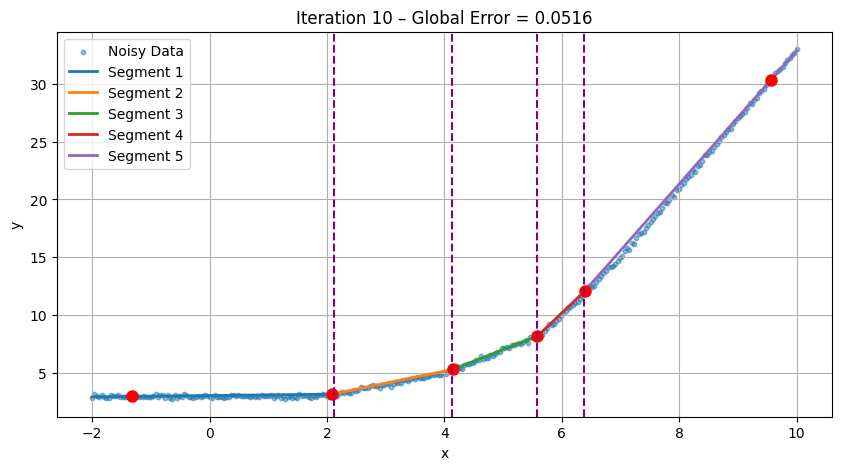

Threshold 1 moved by 0.0109 → new = 2.1301
Threshold 2 moved by -0.0175 → new = 4.1154
Threshold 3 moved by 0.0620 → new = 5.6364
Threshold 4 moved by 0.1508 → new = 6.5353


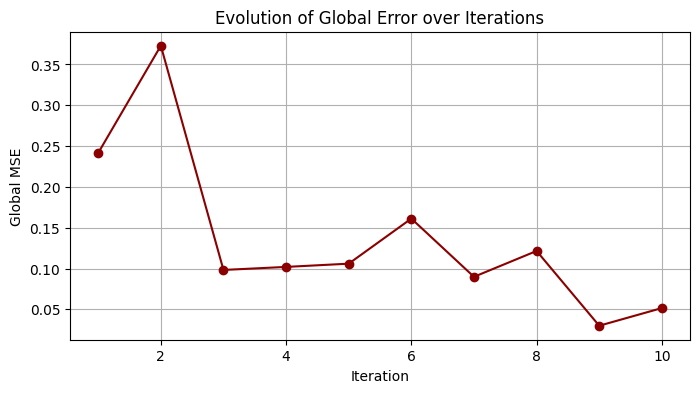

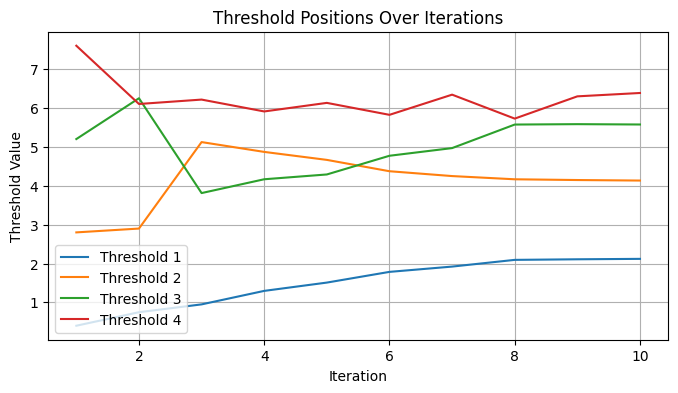

In [20]:
def tropical_poly(x):
    return np.maximum.reduce([x + 1, -3 + 2 * x, np.full_like(x, 3), -20 + 5*x, -27 + 6*x])

x_vals = np.linspace(-2, 10, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.1, size=len(x_vals))

# --- Tropical Regression avec itérations et ajustement des seuils ---
def tropical_regression_manual_k(x, y, k=5, n_iter=10, alpha=2.5, w=0.5):
    thresholds = list(np.linspace(np.min(x), np.max(x), k+1)[1:-1])
    threshold_history = [[] for _ in range(len(thresholds))]

    print(f"Initial thresholds: {np.round(thresholds, 3)}")

    global_errors = []

    for it in range(n_iter):
        for i, t in enumerate(thresholds):
            threshold_history[i].append(t)

        print(f"\n--- Iteration {it+1} ---")

        anchor_points = anchor_points_from_thresholds(x, y, thresholds,w)

        # --- Points extrêmes (quart gauche et droit) ---
        full_mask_left = x <= thresholds[0]
        full_mask_right = x > thresholds[-1]

        x_left, y_left = x[full_mask_left], y[full_mask_left]
        if len(x_left) >= 4:
            q1 = len(x_left) // 4
            pt_left = median_point_in_range(x_left[:q1], y_left[:q1], x_left[:q1].min(), x_left[:q1].max())
            if pt_left: anchor_points.insert(0, pt_left)

        x_right, y_right = x[full_mask_right], y[full_mask_right]
        if len(x_right) >= 4:
            q3 = len(x_right) // 4
            pt_right = median_point_in_range(x_right[-q3:], y_right[-q3:], x_right[-q3:].min(), x_right[-q3:].max())
            if pt_right: anchor_points.append(pt_right)

        anchor_points = sorted(anchor_points, key=lambda p: p[0])

        # --- Tracé et erreur ---
        global_error = 0
        errors = []

        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")

        for i in range(len(anchor_points) - 1):
            pt1, pt2 = anchor_points[i], anchor_points[i + 1]
            a, b, y_pred = line_from_two_points(pt1, pt2, x)

            # Étendre les extrémités
            if i == 0:
                mask = x <= pt2[0]
            elif i == len(anchor_points) - 2:
                mask = x >= pt1[0]
            else:
                mask = (x >= pt1[0]) & (x <= pt2[0])

            error = compute_error(x, y, y_pred, mask)
            errors.append(error)
            global_error += error * np.sum(mask)

            print(f"Segment {i+1} | x ∈ [{pt1[0]:.2f}, {pt2[0]:.2f}] → MSE = {error:.5f}")
            plt.plot(x[mask], y_pred[mask], linewidth=2, label=f"Segment {i+1}")

        # --- Affichage des points et seuils ---
        for px, py in anchor_points:
            plt.plot(px, py, 'ro', markersize=8)
        for t in thresholds:
            plt.axvline(t, color='purple', linestyle='--')
        plt.title(f"Iteration {it+1} – Global Error = {global_error/len(x):.4f}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

        # --- Déplacement des seuils ---
        for i in range(len(thresholds)):
            err_left = errors[i]
            err_right = errors[i + 1]
            move = alpha * (err_right - err_left)
            thresholds[i] += move
            print(f"Threshold {i+1} moved by {move:.4f} → new = {thresholds[i]:.4f}")
            
            
        global_errors.append(global_error / len(x))

    # --- Plot global error evolution ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_iter + 1), global_errors, marker='o', color='darkred')
    plt.title("Evolution of Global Error over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Global MSE")
    plt.grid(True)
    plt.show()

    # --- Plot threshold evolution ---
    plt.figure(figsize=(8, 4))
    for i, t_vals in enumerate(threshold_history):
        plt.plot(range(1, n_iter + 1), t_vals, label=f"Threshold {i+1}")
    plt.title("Threshold Positions Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Threshold Value")
    plt.grid(True)
    plt.legend()
    plt.show()


tropical_regression_manual_k(x_vals, y_noisy, k=5, n_iter=10, alpha=2, w= 0.05)

Initial thresholds: [0.4 2.8 5.2 7.6]

--- Iteration 1 ---
Segment 1 | x ∈ [-2.00, 0.37] → MSE = 0.00814
Segment 2 | x ∈ [0.37, 2.78] → MSE = 0.12138
Segment 3 | x ∈ [2.78, 5.22] → MSE = 0.15052
Segment 4 | x ∈ [5.22, 7.59] → MSE = 0.68984
Segment 5 | x ∈ [7.59, 9.72] → MSE = 0.02020


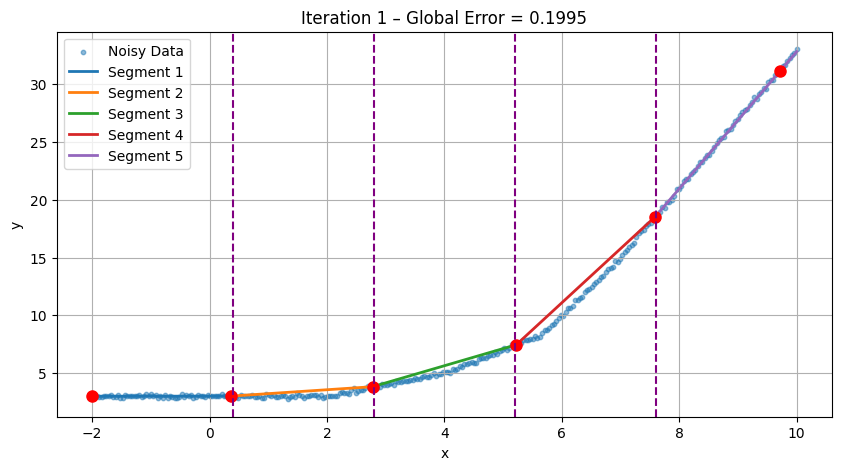

Threshold 1 moved by 0.2265 → new = 0.6265
Threshold 2 moved by 0.0583 → new = 2.8583
Threshold 3 moved by 1.0787 → new = 6.2787
Threshold 4 moved by -1.3393 → new = 6.2607

--- Iteration 2 ---
Segment 1 | x ∈ [-1.76, 0.61] → MSE = 0.00823
Segment 2 | x ∈ [0.61, 2.86] → MSE = 0.07750
Segment 3 | x ∈ [2.86, 6.27] → MSE = 1.37941
Segment 4 | x ∈ [6.27, 6.31] → MSE = 0.00000
Segment 5 | x ∈ [6.31, 9.56] → MSE = 0.08000


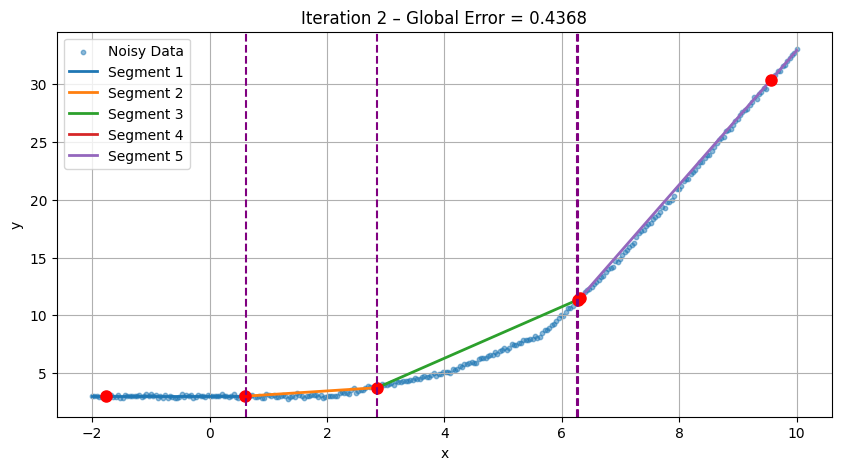

Threshold 1 moved by 0.1385 → new = 0.7650
Threshold 2 moved by 2.6038 → new = 5.4621
Threshold 3 moved by -2.7588 → new = 3.5198
Threshold 4 moved by 0.1600 → new = 6.4207

--- Iteration 3 ---
Segment 1 | x ∈ [-1.76, 0.77] → MSE = 0.01066
Segment 2 | x ∈ [0.77, 3.50] → MSE = 0.15439
Segment 3 | x ∈ [3.50, 5.46] → MSE = 0.07297
Segment 4 | x ∈ [5.46, 6.43] → MSE = 0.09941
Segment 5 | x ∈ [6.43, 9.60] → MSE = 0.07373


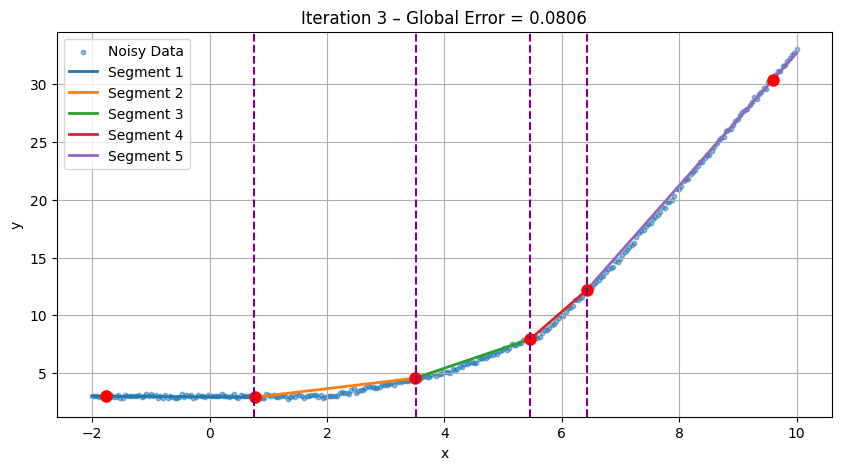

Threshold 1 moved by 0.2874 → new = 1.0525
Threshold 2 moved by -0.1628 → new = 5.2993
Threshold 3 moved by 0.0529 → new = 3.5727
Threshold 4 moved by -0.0514 → new = 6.3693

--- Iteration 4 ---
Segment 1 | x ∈ [-1.28, 1.01] → MSE = 0.00987
Segment 2 | x ∈ [1.01, 3.54] → MSE = 0.13991
Segment 3 | x ∈ [3.54, 5.30] → MSE = 0.03810
Segment 4 | x ∈ [5.30, 6.39] → MSE = 0.19659
Segment 5 | x ∈ [6.39, 9.60] → MSE = 0.08100


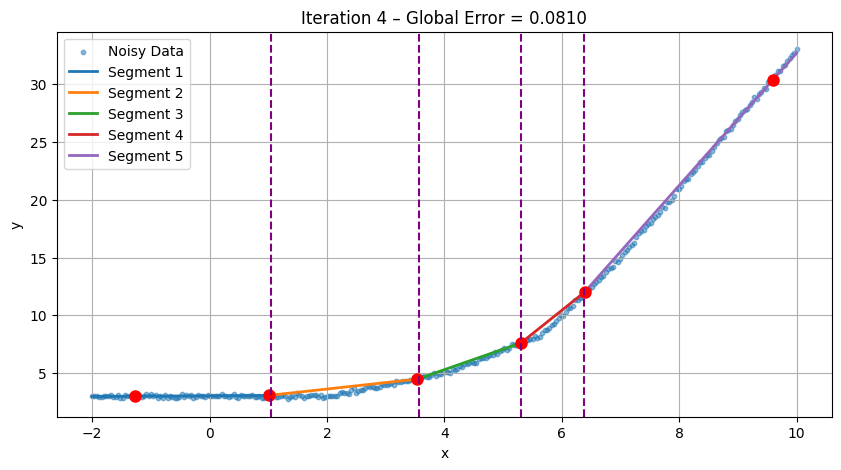

Threshold 1 moved by 0.2601 → new = 1.3125
Threshold 2 moved by -0.2036 → new = 5.0957
Threshold 3 moved by 0.3170 → new = 3.8897
Threshold 4 moved by -0.2312 → new = 6.1382

--- Iteration 5 ---
Segment 1 | x ∈ [-1.28, 1.29] → MSE = 0.00873
Segment 2 | x ∈ [1.29, 3.90] → MSE = 0.12421
Segment 3 | x ∈ [3.90, 5.10] → MSE = 0.01481
Segment 4 | x ∈ [5.10, 6.15] → MSE = 0.16267
Segment 5 | x ∈ [6.15, 9.56] → MSE = 0.10876


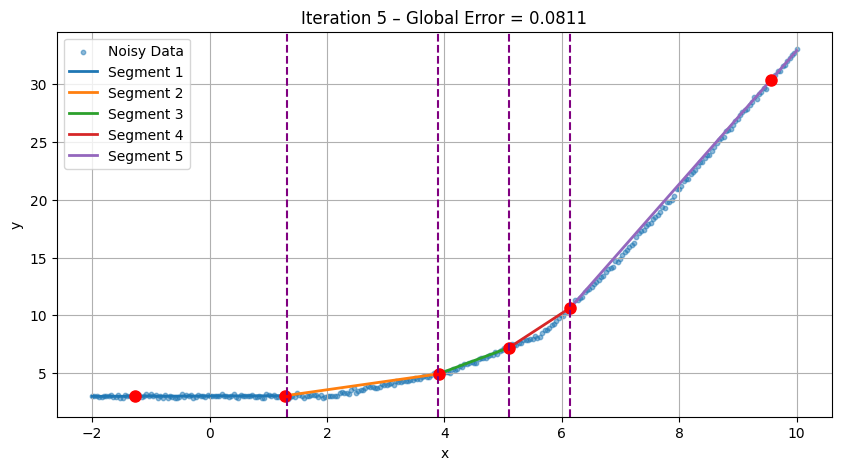

Threshold 1 moved by 0.2310 → new = 1.5435
Threshold 2 moved by -0.2188 → new = 4.8769
Threshold 3 moved by 0.2957 → new = 4.1854
Threshold 4 moved by -0.1078 → new = 6.0303

--- Iteration 6 ---
Segment 1 | x ∈ [-1.28, 1.53] → MSE = 0.01124
Segment 2 | x ∈ [1.53, 4.22] → MSE = 0.10983
Segment 3 | x ∈ [4.22, 4.86] → MSE = 0.01259
Segment 4 | x ∈ [4.86, 5.99] → MSE = 0.19174
Segment 5 | x ∈ [5.99, 9.56] → MSE = 0.19024


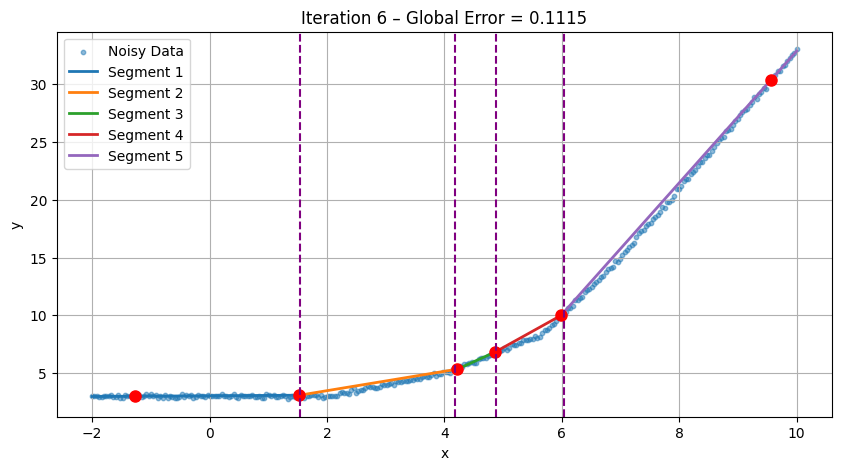

Threshold 1 moved by 0.1972 → new = 1.7407
Threshold 2 moved by -0.1945 → new = 4.6824
Threshold 3 moved by 0.3583 → new = 4.5437
Threshold 4 moved by -0.0030 → new = 6.0273

--- Iteration 7 ---
Segment 1 | x ∈ [-2.00, 1.77] → MSE = 0.01103
Segment 2 | x ∈ [1.77, 4.54] → MSE = 0.10012
Segment 3 | x ∈ [4.54, 4.66] → MSE = 0.00776
Segment 4 | x ∈ [4.66, 5.99] → MSE = 0.18443
Segment 5 | x ∈ [5.99, 9.56] → MSE = 0.19024


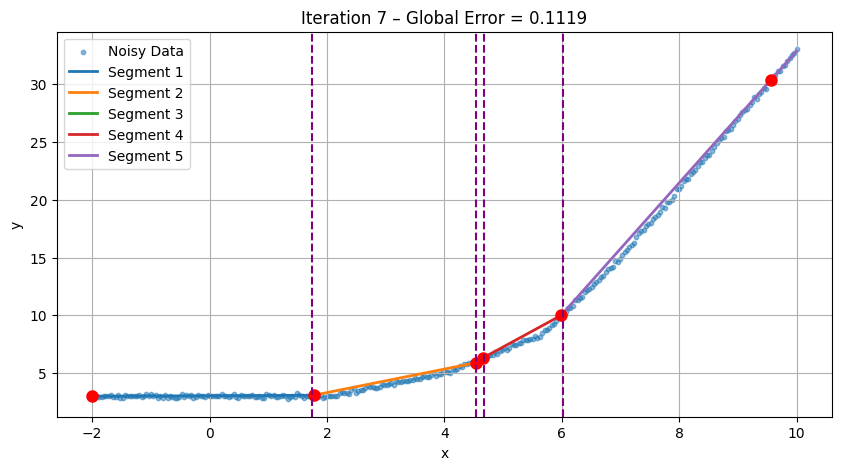

Threshold 1 moved by 0.1782 → new = 1.9189
Threshold 2 moved by -0.1847 → new = 4.4977
Threshold 3 moved by 0.3533 → new = 4.8971
Threshold 4 moved by 0.0116 → new = 6.0389

--- Iteration 8 ---
Segment 1 | x ∈ [-1.28, 1.89] → MSE = 0.01333
Segment 2 | x ∈ [1.89, 4.54] → MSE = 0.08258
Segment 3 | x ∈ [4.54, 4.86] → MSE = 0.01007
Segment 4 | x ∈ [4.86, 6.07] → MSE = 0.20420
Segment 5 | x ∈ [6.07, 9.56] → MSE = 0.13040


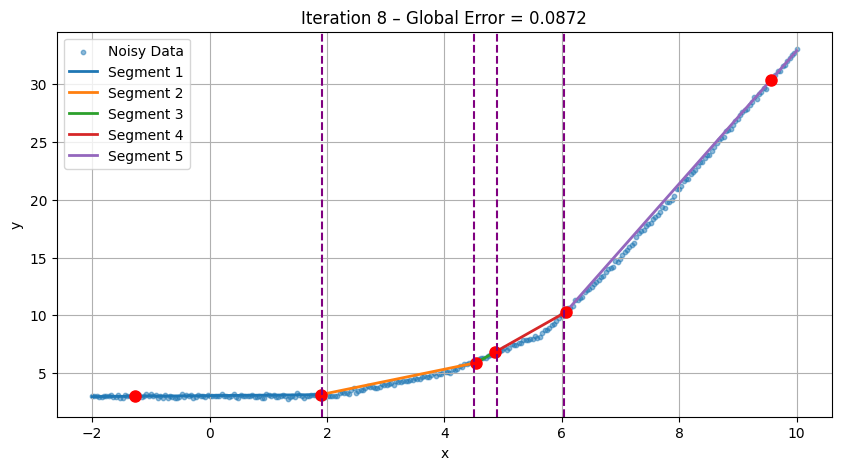

Threshold 1 moved by 0.1385 → new = 2.0574
Threshold 2 moved by -0.1450 → new = 4.3526
Threshold 3 moved by 0.3883 → new = 5.2853
Threshold 4 moved by -0.1476 → new = 5.8914

--- Iteration 9 ---
Segment 1 | x ∈ [-1.04, 2.05] → MSE = 0.00936
Segment 2 | x ∈ [2.05, 4.34] → MSE = 0.06368
Segment 3 | x ∈ [4.34, 5.30] → MSE = 0.01609
Segment 4 | x ∈ [5.30, 5.91] → MSE = 0.06335
Segment 5 | x ∈ [5.91, 9.52] → MSE = 0.22354


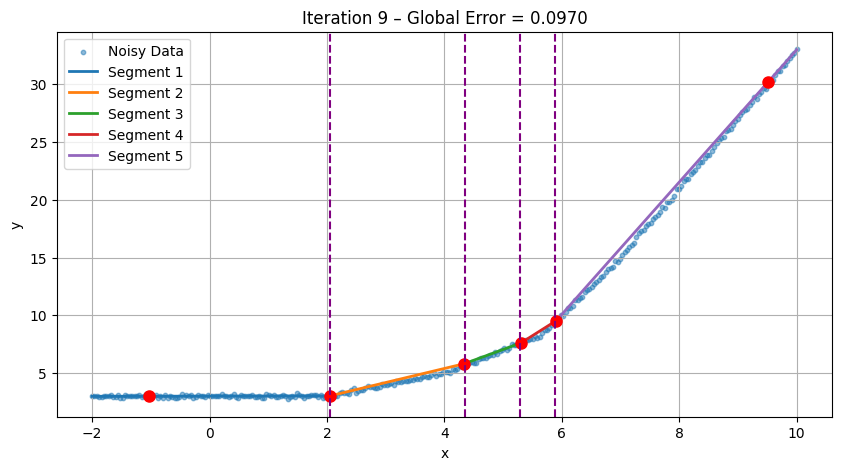

Threshold 1 moved by 0.1086 → new = 2.1660
Threshold 2 moved by -0.0952 → new = 4.2575
Threshold 3 moved by 0.0945 → new = 5.3798
Threshold 4 moved by 0.3204 → new = 6.2117

--- Iteration 10 ---
Segment 1 | x ∈ [-1.28, 2.13] → MSE = 0.00942
Segment 2 | x ∈ [2.13, 4.30] → MSE = 0.01475
Segment 3 | x ∈ [4.30, 5.38] → MSE = 0.00931
Segment 4 | x ∈ [5.38, 6.23] → MSE = 0.20079
Segment 5 | x ∈ [6.23, 9.56] → MSE = 0.18798


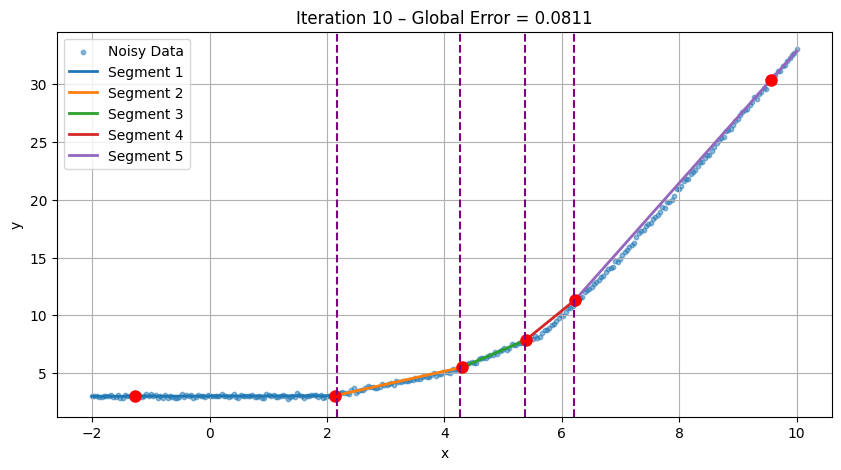

Threshold 1 moved by 0.0107 → new = 2.1767
Threshold 2 moved by -0.0109 → new = 4.2466
Threshold 3 moved by 0.3830 → new = 5.7628
Threshold 4 moved by -0.0256 → new = 6.1861

--- Iteration 11 ---
Segment 1 | x ∈ [-1.28, 2.13] → MSE = 0.00942
Segment 2 | x ∈ [2.13, 4.26] → MSE = 0.03705
Segment 3 | x ∈ [4.26, 5.79] → MSE = 0.05712
Segment 4 | x ∈ [5.79, 6.19] → MSE = 0.00531
Segment 5 | x ∈ [6.19, 9.56] → MSE = 0.09233


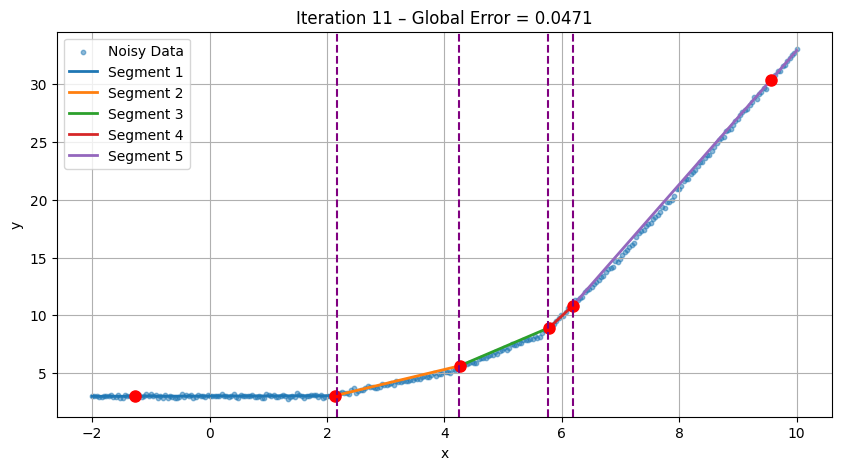

Threshold 1 moved by 0.0553 → new = 2.2319
Threshold 2 moved by 0.0401 → new = 4.2867
Threshold 3 moved by -0.1036 → new = 5.6592
Threshold 4 moved by 0.1740 → new = 6.3602

--- Iteration 12 ---
Segment 1 | x ∈ [-1.28, 2.25] → MSE = 0.04368
Segment 2 | x ∈ [2.25, 4.26] → MSE = 0.06473
Segment 3 | x ∈ [4.26, 5.67] → MSE = 0.02411
Segment 4 | x ∈ [5.67, 6.39] → MSE = 0.01893
Segment 5 | x ∈ [6.39, 9.60] → MSE = 0.08100


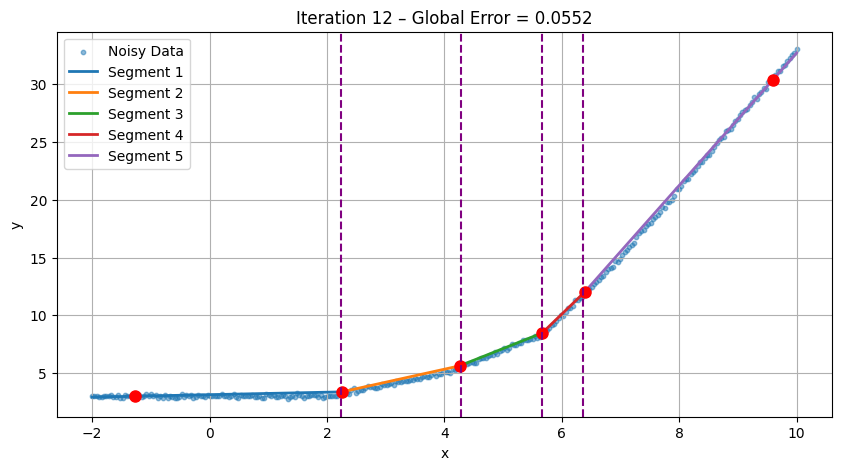

Threshold 1 moved by 0.0421 → new = 2.2740
Threshold 2 moved by -0.0812 → new = 4.2055
Threshold 3 moved by -0.0103 → new = 5.6488
Threshold 4 moved by 0.1241 → new = 6.4843

--- Iteration 13 ---
Segment 1 | x ∈ [-1.28, 2.25] → MSE = 0.04368
Segment 2 | x ∈ [2.25, 4.22] → MSE = 0.02193
Segment 3 | x ∈ [4.22, 5.67] → MSE = 0.01369
Segment 4 | x ∈ [5.67, 6.51] → MSE = 0.01046
Segment 5 | x ∈ [6.51, 9.60] → MSE = 0.03188


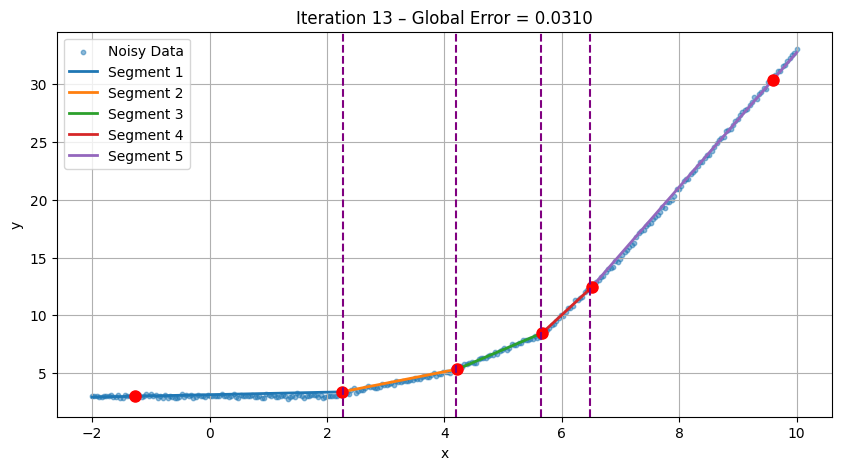

Threshold 1 moved by -0.0435 → new = 2.2305
Threshold 2 moved by -0.0165 → new = 4.1890
Threshold 3 moved by -0.0065 → new = 5.6424
Threshold 4 moved by 0.0429 → new = 6.5271

--- Iteration 14 ---
Segment 1 | x ∈ [-1.28, 2.25] → MSE = 0.04368
Segment 2 | x ∈ [2.25, 4.22] → MSE = 0.02193
Segment 3 | x ∈ [4.22, 5.67] → MSE = 0.01369
Segment 4 | x ∈ [5.67, 6.55] → MSE = 0.01282
Segment 5 | x ∈ [6.55, 9.60] → MSE = 0.04234


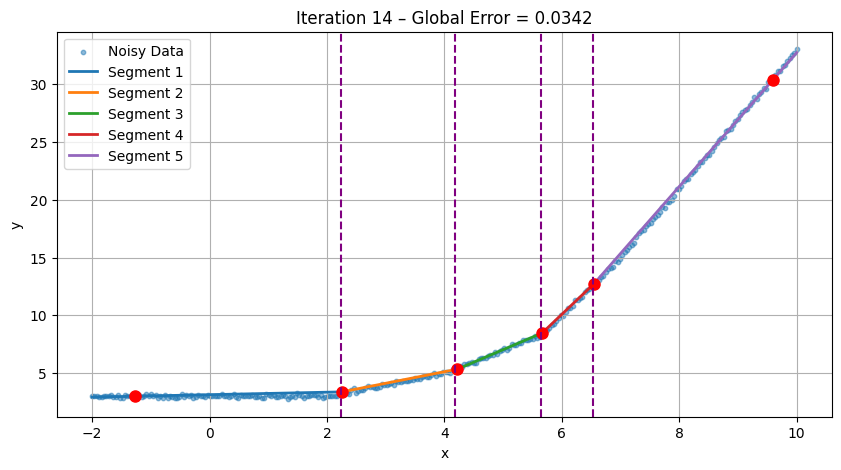

Threshold 1 moved by -0.0435 → new = 2.1870
Threshold 2 moved by -0.0165 → new = 4.1725
Threshold 3 moved by -0.0017 → new = 5.6406
Threshold 4 moved by 0.0590 → new = 6.5862

--- Iteration 15 ---
Segment 1 | x ∈ [-1.28, 2.21] → MSE = 0.02597
Segment 2 | x ∈ [2.21, 4.22] → MSE = 0.01461
Segment 3 | x ∈ [4.22, 5.67] → MSE = 0.01369
Segment 4 | x ∈ [5.67, 6.59] → MSE = 0.00991
Segment 5 | x ∈ [6.59, 9.60] → MSE = 0.02846


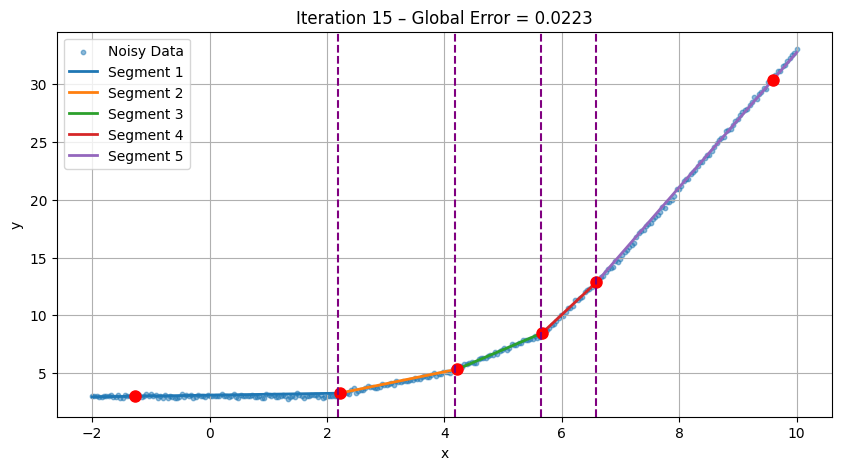

Threshold 1 moved by -0.0227 → new = 2.1643
Threshold 2 moved by -0.0018 → new = 4.1707
Threshold 3 moved by -0.0076 → new = 5.6330
Threshold 4 moved by 0.0371 → new = 6.6233

--- Iteration 16 ---
Segment 1 | x ∈ [-1.28, 2.13] → MSE = 0.00942
Segment 2 | x ∈ [2.13, 4.14] → MSE = 0.01804
Segment 3 | x ∈ [4.14, 5.63] → MSE = 0.01857
Segment 4 | x ∈ [5.63, 6.63] → MSE = 0.01268
Segment 5 | x ∈ [6.63, 9.60] → MSE = 0.02515


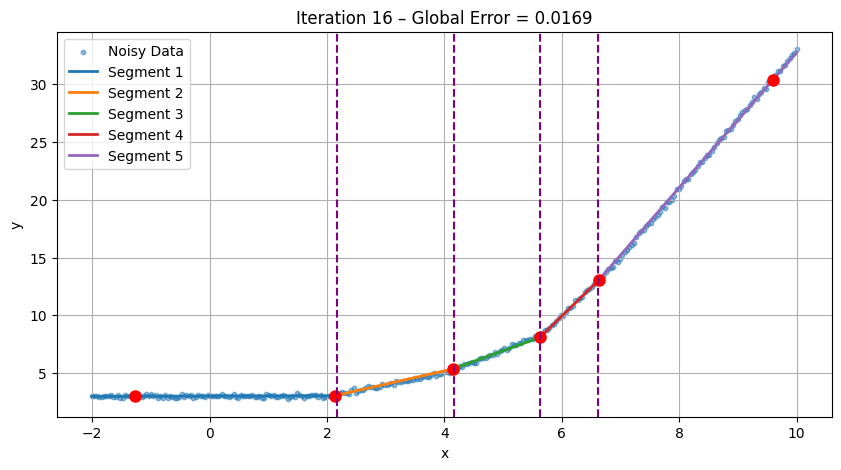

Threshold 1 moved by 0.0172 → new = 2.1815
Threshold 2 moved by 0.0011 → new = 4.1717
Threshold 3 moved by -0.0118 → new = 5.6213
Threshold 4 moved by 0.0249 → new = 6.6482

--- Iteration 17 ---
Segment 1 | x ∈ [-1.28, 2.13] → MSE = 0.00942
Segment 2 | x ∈ [2.13, 4.22] → MSE = 0.01068
Segment 3 | x ∈ [4.22, 5.63] → MSE = 0.02899
Segment 4 | x ∈ [5.63, 6.67] → MSE = 0.01026
Segment 5 | x ∈ [6.67, 9.60] → MSE = 0.02978


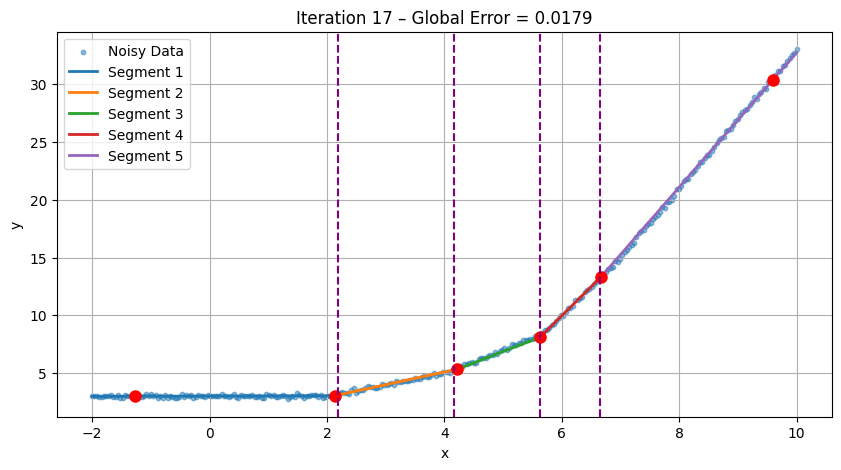

Threshold 1 moved by 0.0025 → new = 2.1840
Threshold 2 moved by 0.0366 → new = 4.2084
Threshold 3 moved by -0.0375 → new = 5.5838
Threshold 4 moved by 0.0390 → new = 6.6873

--- Iteration 18 ---
Segment 1 | x ∈ [-1.28, 2.21] → MSE = 0.02597
Segment 2 | x ∈ [2.21, 4.22] → MSE = 0.01461
Segment 3 | x ∈ [4.22, 5.63] → MSE = 0.02899
Segment 4 | x ∈ [5.63, 6.71] → MSE = 0.01238
Segment 5 | x ∈ [6.71, 9.64] → MSE = 0.01599


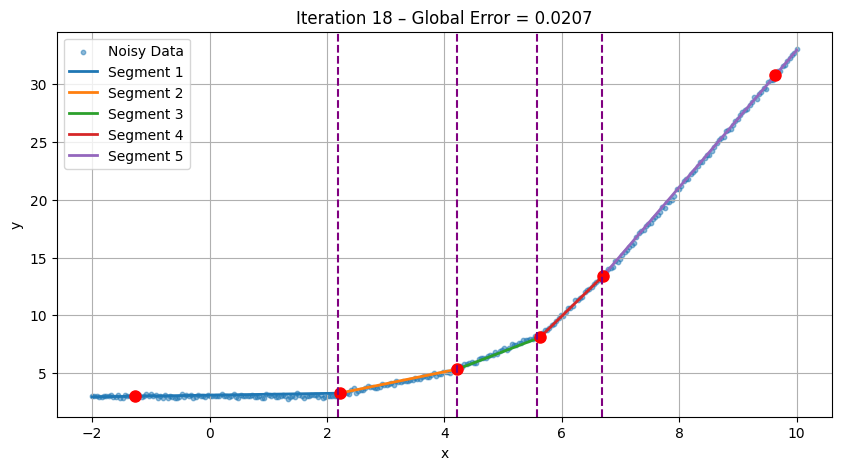

Threshold 1 moved by -0.0227 → new = 2.1613
Threshold 2 moved by 0.0288 → new = 4.2371
Threshold 3 moved by -0.0332 → new = 5.5506
Threshold 4 moved by 0.0072 → new = 6.6945

--- Iteration 19 ---
Segment 1 | x ∈ [-1.28, 2.13] → MSE = 0.00942
Segment 2 | x ∈ [2.13, 4.26] → MSE = 0.03705
Segment 3 | x ∈ [4.26, 5.59] → MSE = 0.01830
Segment 4 | x ∈ [5.59, 6.71] → MSE = 0.00779
Segment 5 | x ∈ [6.71, 9.64] → MSE = 0.01599


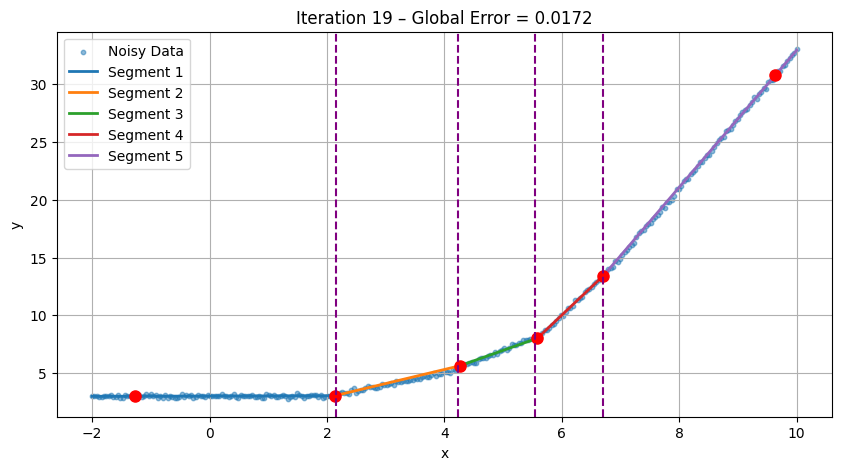

Threshold 1 moved by 0.0553 → new = 2.2165
Threshold 2 moved by -0.0375 → new = 4.1996
Threshold 3 moved by -0.0210 → new = 5.5295
Threshold 4 moved by 0.0164 → new = 6.7109

--- Iteration 20 ---
Segment 1 | x ∈ [-1.28, 2.21] → MSE = 0.02597
Segment 2 | x ∈ [2.21, 4.22] → MSE = 0.01461
Segment 3 | x ∈ [4.22, 5.55] → MSE = 0.00996
Segment 4 | x ∈ [5.55, 6.71] → MSE = 0.05453
Segment 5 | x ∈ [6.71, 9.64] → MSE = 0.01599


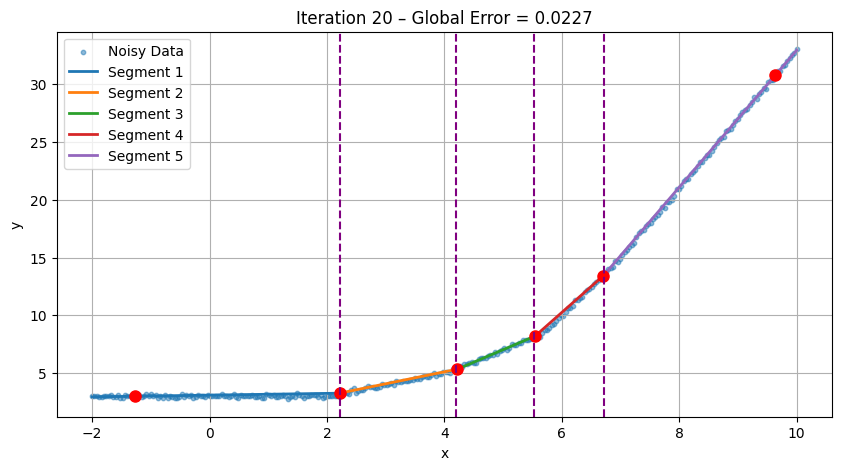

Threshold 1 moved by -0.0227 → new = 2.1938
Threshold 2 moved by -0.0093 → new = 4.1903
Threshold 3 moved by 0.0891 → new = 5.6187
Threshold 4 moved by -0.0771 → new = 6.6338


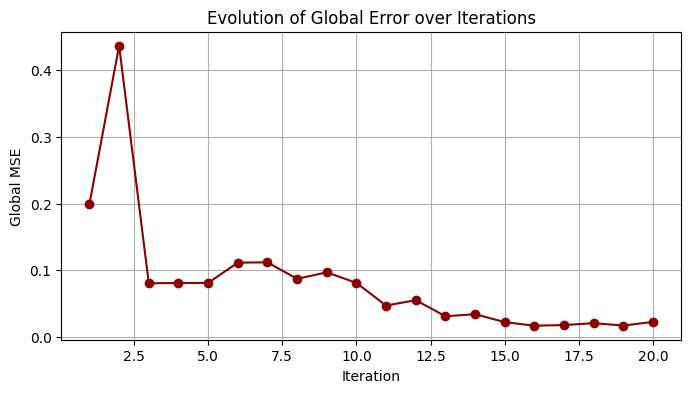

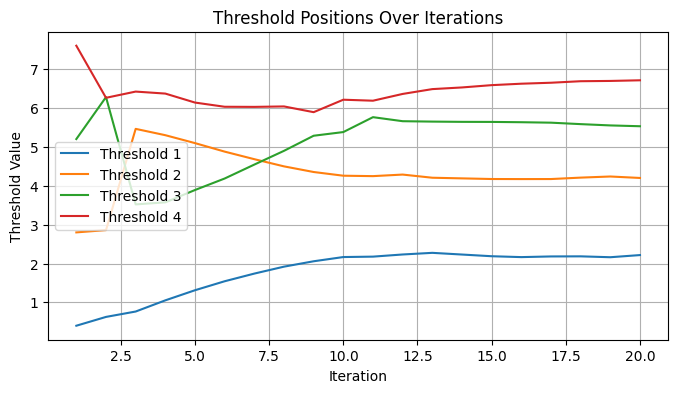

In [24]:
#def tropical_poly(x):
    #return np.maximum.reduce([x + 1, -3 + 2 * x, np.full_like(x, 3)])

def tropical_poly(x):
    return np.maximum.reduce([x + 1, -3 + 2 * x, np.full_like(x, 3), -20 + 5*x, -27 + 6*x])

#def tropical_poly(x):
    #return np.maximum.reduce([x + 1, np.full_like(x, 3)])

x_vals = np.linspace(-2, 10, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.1, size=len(x_vals))

# --- Tropical Regression avec itérations et ajustement des seuils ---
def tropical_regression_manual_k(x, y, k=5, n_iter=10, alpha=2.5, w=0.5):
    thresholds = list(np.linspace(np.min(x), np.max(x), k+1)[1:-1])
    threshold_history = [[] for _ in range(len(thresholds))]

    print(f"Initial thresholds: {np.round(thresholds, 3)}")

    global_errors = []

    for it in range(n_iter):
        for i, t in enumerate(thresholds):
            threshold_history[i].append(t)

        print(f"\n--- Iteration {it+1} ---")

        anchor_points = anchor_points_from_thresholds(x, y, thresholds,w)

        # --- Points extrêmes (quart gauche et droit) ---
        full_mask_left = x <= thresholds[0]
        full_mask_right = x > thresholds[-1]

        x_left, y_left = x[full_mask_left], y[full_mask_left]
        if len(x_left) >= 4:
            q1 = len(x_left) // 4
            pt_left = median_point_in_range(x_left[:q1], y_left[:q1], x_left[:q1].min(), x_left[:q1].max())
            if pt_left: anchor_points.insert(0, pt_left)

        x_right, y_right = x[full_mask_right], y[full_mask_right]
        if len(x_right) >= 4:
            q3 = len(x_right) // 4
            pt_right = median_point_in_range(x_right[-q3:], y_right[-q3:], x_right[-q3:].min(), x_right[-q3:].max())
            if pt_right: anchor_points.append(pt_right)

        anchor_points = sorted(anchor_points, key=lambda p: p[0])

        # --- Tracé et erreur ---
        global_error = 0
        errors = []

        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s=10, alpha=0.5, label="Noisy Data")

        for i in range(len(anchor_points) - 1):
            pt1, pt2 = anchor_points[i], anchor_points[i + 1]
            a, b, y_pred = line_from_two_points(pt1, pt2, x)

            # Étendre les extrémités
            if i == 0:
                mask = x <= pt2[0]
            elif i == len(anchor_points) - 2:
                mask = x >= pt1[0]
            else:
                mask = (x >= pt1[0]) & (x <= pt2[0])

            error = compute_error(x, y, y_pred, mask)
            errors.append(error)
            global_error += error * np.sum(mask)

            print(f"Segment {i+1} | x ∈ [{pt1[0]:.2f}, {pt2[0]:.2f}] → MSE = {error:.5f}")
            plt.plot(x[mask], y_pred[mask], linewidth=2, label=f"Segment {i+1}")

        # --- Affichage des points et seuils ---
        for px, py in anchor_points:
            plt.plot(px, py, 'ro', markersize=8)
        for t in thresholds:
            plt.axvline(t, color='purple', linestyle='--')
        plt.title(f"Iteration {it+1} – Global Error = {global_error/len(x):.4f}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

        # --- Déplacement des seuils ---
        for i in range(len(thresholds)):
            err_left = errors[i]
            err_right = errors[i + 1]
            move = alpha * (err_right - err_left)
            thresholds[i] += move
            print(f"Threshold {i+1} moved by {move:.4f} → new = {thresholds[i]:.4f}")
            
            
        global_errors.append(global_error / len(x))

    # --- Plot global error evolution ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_iter + 1), global_errors, marker='o', color='darkred')
    plt.title("Evolution of Global Error over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Global MSE")
    plt.grid(True)
    plt.show()

    # --- Plot threshold evolution ---
    plt.figure(figsize=(8, 4))
    for i, t_vals in enumerate(threshold_history):
        plt.plot(range(1, n_iter + 1), t_vals, label=f"Threshold {i+1}")
    plt.title("Threshold Positions Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Threshold Value")
    plt.grid(True)
    plt.legend()
    plt.show()


tropical_regression_manual_k(x_vals, y_noisy, k=5, n_iter=20, alpha=2, w= 0.05)

✅ Estimated number of linear segments (from slope clustering): 2


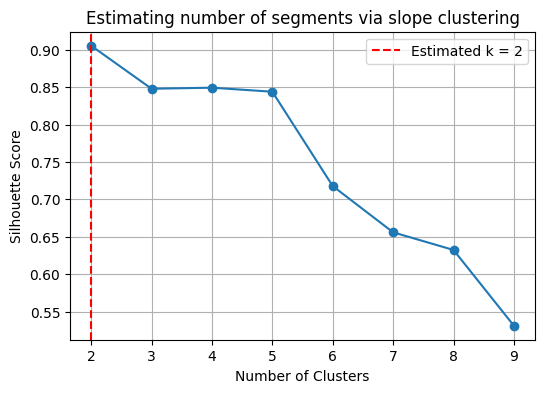

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Tropical Polynomial ---
def tropical_poly(x):
    return np.maximum.reduce([
        x + 1,
        -5 + 2 * x,
        np.full_like(x, 3),
        -27 + 6 * x
    ])

# --- Generate noisy data ---
np.random.seed(0)
x_vals = np.linspace(-2, 10, 300)
y_true = tropical_poly(x_vals)
y_noisy = y_true + np.random.normal(0, 0.1, size=len(x_vals))

# --- Sliding window regression ---
window_size = 15
slopes = []
positions = []

for i in range(len(x_vals) - window_size):
    x_win = x_vals[i:i+window_size].reshape(-1, 1)
    y_win = y_noisy[i:i+window_size]
    
    model = LinearRegression().fit(x_win, y_win)
    slope = model.coef_[0]
    
    slopes.append(slope)
    positions.append(np.mean(x_win))

slopes = np.array(slopes).reshape(-1, 1)

# --- Clustering of slopes ---
silhouettes = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(slopes)
    score = silhouette_score(slopes, kmeans.labels_)
    silhouettes.append(score)

best_k = K_range[np.argmax(silhouettes)]
print(f"✅ Estimated number of linear segments (from slope clustering): {best_k}")

# --- Optional: visualize silhouette curve ---
plt.figure(figsize=(6, 4))
plt.plot(K_range, silhouettes, 'o-')
plt.axvline(best_k, color='red', linestyle='--', label=f"Estimated k = {best_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Estimating number of segments via slope clustering")
plt.legend()
plt.grid(True)
plt.show()
